# Avance 4. Modelos alternativos

El objetivo de este notebook es construir múltiples modelos (individuales, no ensambles) relevantes para realizar el pronóstico y evaluar su desempeño. Diferentes algoritmos pueden comportarse de manera óptima en diferentes tipos de datos o tareas. La construcción de modelos alternativos permite explorar y evaluar cuál de ellos proporciona el mejor rendimiento para un problema particular. Para esto será necesario:

* Explorar una gama diversa de técnicas y enfoques con el fin de identificar el de mejor desempeño en el conjunto de datos en cuestión.

* Encontrar la configuración óptima que maximiza el rendimiento del modelo en una tarea específica.

## 1. Librerías y Carga de Datos.

* Se define si se utilizará Plotly para las gráficas y se importan las librerías necesarias para análisis de datos, visualización y modelado de series temporales.

Recomendaciones:  Para un mejor entendimiento de las gráficas o su uso local cambiar el valor de `USE_PLOTRLY` a `True`

In [1]:
# Control de visualización: desactivar Plotly para generar gráficas con Matplotlib/Seaborn en este notebook.
USE_PLOTLY = False
# Nota: Plotly puede habilitarse para uso local cambiando a True si se desea interactividad.

### 1.1. Librerías

In [9]:
import sys
sys.path.append('../../')
import src.utils.helpers as func
import src.evaluation.metrics as meval
from src.features.build_features import create_basic_time_features, prepare_data
from src.utils.ts_diagnostics import StationarityAnalyzer, analyze_decomposition
from src.visualization import tsa_plots as tsp
from src.evaluation.interpretability import get_xbg_feature_importance
from src.evaluation.plots import plot_last_year, plot_residuals_distribution, plot_forecast

In [3]:
from statsmodels.tsa.api import ExponentialSmoothing
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf as sm_plot_acf
import numpy as np
import plotly.graph_objects as go
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd
from tabulate import tabulate
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2, f_classif
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import prince as pr
import plotly.express as px
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

### 1.2. Carga de Datos

In [4]:
# Usar df_log como dataset base para estos modelos
# path = r'C:\Users\naomi\proyecto_depresion\proyecto-integrador-mna\data\processed\df_log.parquet'
path = '../../data/processed/df_log.parquet'

# Cargar datos (sin mostrar información para reducir salida de notebook)
df_log = func.load_data(path, show_info=False)

Cargando datos desde: ../../data/processed/df_log.parquet
Datos cargados exitosamente.


### 1.3 Argumentos Comunes para Graficar

In [4]:
# Los parámetros comunes del gráfico
common_plot_args = {
    'plotly_engine': USE_PLOTLY,
    'hover_mode': 'x unified',
}

## 2. Modelos clásicos

### 2.1. Baseline: Holt-Winters
* Se ordena el DataFrame por fecha, se establece el índice temporal y se divide el conjunto de datos en entrenamiento (80%) y prueba (20%) para validar el modelo.

In [6]:
# índice temporal
data = df_log.copy().sort_values('fecha')
data = data.set_index('fecha').asfreq('W-MON')

scaled_method = 'log'
train, test = func.split_series(data, train_size=0.8)

Total de datos: 573
Tamaño del conjunto de entrenamiento: 458
Tamaño del conjunto de prueba: 115


* Se ajusta el modelo de suavizamiento exponencial doble utilizando únicamente el conjunto de entrenamiento.

In [7]:
model_triple = ExponentialSmoothing(
    train, 
    seasonal_periods=52, 
    trend='mul', 
    seasonal='add')

model_triple_fit = model_triple.fit()

* Se realiza el pronóstico para el periodo de prueba utilizando el modelo ajustado.

In [8]:
forecast_triple = model_triple_fit.forecast(115)

* Se transforman los valores ajustados y pronosticados de la escala logarítmica a la escala original para facilitar la interpretación

In [9]:
method = 'log'
train_org = func.get_original_scale_dataframe(train, method=scaled_method)
test_org = func.get_original_scale_dataframe(test, method=scaled_method)
df_original = func.get_original_scale_dataframe(data, method=method)
df_ajustado = func.get_original_scale_dataframe(model_triple_fit.fittedvalues, method=method)
df_pronostico = func.get_original_scale_dataframe(forecast_triple, method=method)

#### 2.1.1. Evaluación del modelo

##### 2.1.1.1. MAE, RMSE y MAPE
* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [10]:
model_metrics = meval.evaluate_model_performance(train_org,test_org,df_ajustado,df_pronostico, label= 'valor_original')

Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 178.691    │
├───────────┼────────────┤
│ RMSE      │ 254.155    │
├───────────┼────────────┤
│ MAPE      │   0.165696 │
╘═══════════╧════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 364.08     │
├───────────┼────────────┤
│ RMSE      │ 502.859    │
├───────────┼────────────┤
│ MAPE      │   0.147398 │
╘═══════════╧════════════╛


El análisis del modelo de Holt-Winters revela un comportamiento que sugiere una pérdida de precisión en el error absoluto al evaluar la capacidad de generalización. En el conjunto de entrenamiento, el modelo ajusta la serie con un Error Absoluto Medio (MAE) de $178.69$ y una Raíz del Error Cuadrático Medio (RMSE) de $254.16$. No obstante, al pronosticar sobre el conjunto de prueba, los errores absolutos se incrementan notablemente a MAE de $364.08$ y RMSE de $502.86$, lo que indica que el modelo no extrapola con precisión los valores exactos en unidades de casos no vistos. Pese a este deterioro en el error absoluto, el Error Porcentual Absoluto Medio (MAPE) en la prueba es inferior ($14.74\%$) al de entrenamiento ($16.57\%$). Este patrón sugiere que, aunque el error de pronóstico es mayor en magnitud, es proporcionalmente menor respecto a los valores reales de la serie en el periodo de prueba, demostrando una estabilidad porcentual aceptable y una capacidad robusta para capturar la tendencia subyacente y la estacionalidad del fenómeno.

##### 2.1.1.2. Análisis de errores
* Se realiza una visualización para análisis de errores (residuos)

In [11]:
plot_residuals_distribution(train_org,df_ajustado, plotly_engine = USE_PLOTLY, title = 'Análisis de Errores - Conjunto de Entrenamiento')
plot_residuals_distribution(test_org, df_pronostico, plotly_engine = USE_PLOTLY, title = 'Análisis de Errores - Conjunto de Prueba')

En el **conjunto de Entrenamiento**, el histograma de errores se concentra fuertemente en torno a cero, y el gráfico de **Valores Reales vs Predicciones** muestra que los puntos de predicción (naranja) se alinean estrechamente con la **recta de $45^{\circ}$** (línea discontinua), indicando que el modelo replica con alta precisión los datos históricos. En el **conjunto de Prueba**, el histograma de errores sigue manteniendo su centro alrededor de cero, y aunque los puntos en el gráfico de **Valores Reales vs Predicciones** presentan una **mayor dispersión** alrededor de la línea de $45^{\circ}$ en comparación con el entrenamiento, esta **variabilidad es esperable** en datos fuera de muestra y confirma que el modelo no presenta un sesgo sistemático (los errores son aproximadamente simétricos a cero), lo que valida su **capacidad para generar pronósticos imparciales** de los casos semanales de depresión.

#### 2.1.2. Visualización de resultados

##### 2.1.2.1. Entrenamiento y prueba
* Se grafican los datos originales, los valores ajustados y el pronóstico para comparar el desempeño del modelo.

In [12]:

# Los datos a graficar
model_name = 'Modelo Holt / Double Exponential Smoothing'
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
)

# El gráfico base que siempre se muestra
plot_configs = [
    ('valor', 'Valor Semanal log')
]

# El gráfico condicional
if 'valor_original' in df_original.columns:
    plot_configs.append(('valor_original', 'Valor Semanal Sin Transformacion'))


# --- 3. Itera y llama a la función UNA SOLA VEZ dentro del bucle ---
for y_col, title_suffix in plot_configs:
    plot_forecast(
        *data_tuples,  # Desempaqueta los datos
        y=y_col,
        title=f'Comparación de Series {model_name} ({title_suffix})',
        **common_plot_args  # Desempaqueta los argumentos comunes
    )


El gráfico de la Comparación de Series del Modelo Holt / Double Exponential Smoothing revela que el modelo logra una captura efectiva de la tendencia y estacionalidad en los casos semanales de depresión. La curva Ajustada (roja) sigue consistentemente la serie Original (azul) a lo largo del periodo 2014-2024, tanto en la escala logarítmica como en la escala original . Sin embargo, se observa una incapacidad inherente del modelo para reaccionar a la volatilidad abrupta, suavizando los picos más extremos, especialmente a partir de 2022. La serie Pronosticada (verde) en la escala original muestra un patrón de estacionalidad clara y continua en el futuro, pero con una tendencia de crecimiento moderada o plana, limitando la capacidad de anticipar aumentos súbitos. Esto sugiere que el modelo es robusto para la predicción de la media y el ciclo estacional, pero es menos sensible a las desviaciones extremas o cambios estructurales repentinos.

##### 2.1.2.2. Pronóstico adicional
* Se genera un pronóstico adicional para un periodo más largo y se visualiza junto con los datos originales y ajustados.

In [13]:
forecast_triple = model_triple_fit.forecast(200)
df_pronostico2 = func.get_original_scale_dataframe(forecast_triple, method=method)

In [14]:
# --- 1. Define los argumentos que NUNCA cambian ---
# Los datos a graficar
model_name = 'Modelo Holt / Double Exponential Smoothing'
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico2, 'Pronosticada'),
)

# --- 2. Crea la lista de gráficos a generar ---
# El gráfico base que siempre se muestra
plot_configs = [
    ('valor', 'Valor Semanal log')
]

# El gráfico condicional
if 'valor_original' in df_original.columns:
    plot_configs.append(('valor_original', 'Valor Semanal Sin Transformacion'))


# --- 3. Itera y llama a la función UNA SOLA VEZ dentro del bucle ---
for y_col, title_suffix in plot_configs:
    plot_forecast(
        *data_tuples,  # Desempaqueta los datos
        y=y_col,
        title=f'Comparación de Series {model_name} ({title_suffix})',
        **common_plot_args  # Desempaqueta los argumentos comunes
    )

Las gráficas en ambas escalas, logarítmica y original, demuestra la capacidad del modelo para **proyectar la tendencia creciente y la marcada estacionalidad** de los casos semanales de depresión hasta el año 2026. 

La gráfica en la **escala logarítmica** (superior) exhibe un **ajuste y pronóstico notablemente suaves** y estables en la varianza, validando la efectividad de la transformación para estabilizar la serie. 

Por su parte, la gráfica en la **escala original** (inferior) muestra que la **Serie Pronosticada** (verde) proyecta una **aceleración de la tendencia ascendente**, alcanzando niveles superiores a los 4000 casos hacia el final del horizonte de predicción, y **conserva los patrones estacionales recurrentes** (picos y valles anuales). Si bien el modelo ajustado replica de cerca la serie histórica, el pronóstico tiende a **suavizar la volatilidad** en comparación con los picos extremos observados en 2023-2024, lo que sugiere una **predicción de las medias condicionales robusta**, pero potencialmente conservadora en la captura de la magnitud de la varianza en los periodos futuros.

### 2.2. SARIMA y SARIMAX

#### 2.2.1. Transformación y preparación de serie para modelos SARIMA y SARIMAX

* Se realiza un diferenciación a la serie logarítmica para lograr estacionaridad y poder trabajar con otros modelos clásicos.

In [15]:
df_log_diff = df_log.copy()
df_diff1 = df_log_diff.set_index('fecha').diff().dropna().reset_index()

x= 'fecha'
y= 'valor'
title = 'Serie de tiempo General (Casos nuevos semanales)'
# Gráfica de línea con plotly / seaborn según selección del usuario
tsp.plot_timeseries(df_diff1, x=x, y=y, title=title, plotly_engine=USE_PLOTLY)

El gráfico muestra la serie de tiempo de **Casos Nuevos Semanales después de aplicar una diferenciación a la serie transformada logarítmicamente (Log-Diff)**. La diferenciación ha sido **completamente exitosa en eliminar la tendencia** y estabilizar la media de la serie, la cual ahora oscila de manera estable alrededor de cero, cumpliendo con el requisito fundamental de **estacionariedad**. La varianza también es constante, con la mayor parte del ruido concentrada cerca de la línea de base, a excepción de un **valor atípico extremo** alrededor de 2016 y otro al inicio de 2014, lo que sugiere anomalías en el registro de la tasa de crecimiento durante esas semanas.

##### 2.2.1.1. Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido

* Se descompone la serie en sus componentes de tendencia, estacionalidad y ruido para identificar patrones subyacentes.

In [16]:
ts_data_diff1 = df_diff1.set_index('fecha')['valor']

# Mostrar las primeras filas de la serie temporal preparada
print("Serie temporal preparada para descomposición:")
display(ts_data_diff1.head())

Serie temporal preparada para descomposición:


fecha
2014-01-13    1.607922
2014-01-20    0.348753
2014-01-27    0.091995
2014-02-03    0.117783
2014-02-10   -0.216223
Name: valor, dtype: float64

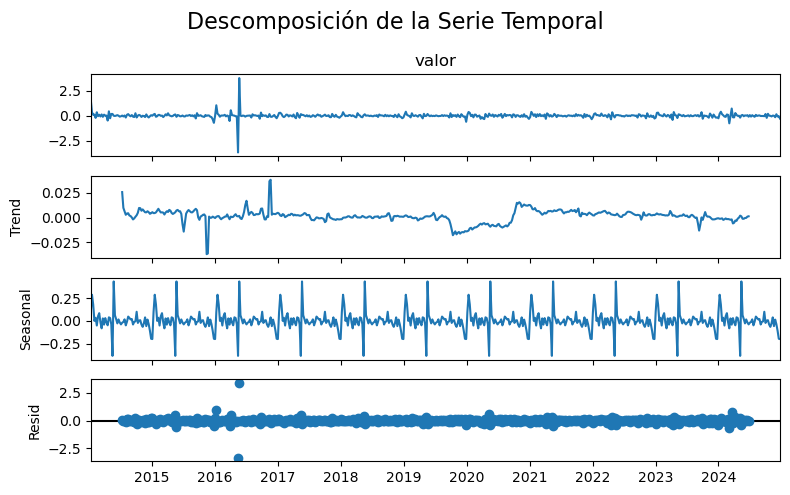

In [17]:
# Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido
decomposition = analyze_decomposition(ts_data_diff1, model='additive', figsize=(8, 5))

**Tendencia (Trend):** La tendencia se ha eliminado por completo, mostrando ahora una línea plana y estable alrededor de cero. Esto confirma que la diferenciación fue exitosa en inducir la estacionariedad en la media, eliminando el crecimiento a largo plazo.

**Estacionalidad (Seasonal):** El patrón cíclico anual persiste, con picos y valles recurrentes, aunque su amplitud se mantiene cerca de cero. Esta estacionalidad no fue eliminada por la diferenciación simple, lo cual es esperado. Este componente estacional deberá ser capturado por la parte estacional ($D=0$) de un modelo SARIMA o con una diferenciación estacional adicional.

**Residuos (Resid):** Muestran una varianza estable con los puntos dispersándose de manera uniforme alrededor de la línea cero. La mayoría de los valores atípicos previos se han mitigado o normalizado, dejando una serie con un ruido más aleatorio y una varianza constante.

La serie de tiempo es estacionaria en media y varianza, gracias a la transformación logarítmica y la diferenciación. El éxito en la eliminación de la tendencia y la preservación de la estacionalidad restante hacen que esta serie esté lista para la aplicación de un modelo SARIMA para el pronóstico.

##### 2.2.1.2. Pruebas de estacionariedad

* Se aplican pruebas estadísticas para determinar si la serie es estacionaria, es decir, si sus propiedades estadísticas son constantes en el tiempo.

In [18]:
tester_ts_data_diff1 = StationarityAnalyzer(ts_data_diff1)

tester_ts_data_diff1.run_test(test_type='ADF', show_report=True)
tester_ts_data_diff1.run_test(test_type='KPSS', show_report=True)


Resultados de la prueba ADF:
╒═════════════════╤════════════════╤════════════════════════╕
│ Métrica         │   Valor Prueba │   Valor Crítico (5.0%) │
╞═════════════════╪════════════════╪════════════════════════╡
│ Estadístico ADF │        -7.9522 │                -2.8668 │
├─────────────────┼────────────────┼────────────────────────┤
│ p-value         │         0      │                 0.05   │
╘═════════════════╧════════════════╧════════════════════════╛

Resultados de la prueba KPSS:
╒══════════════════╤════════════════╤════════════════════════╕
│ Métrica          │   Valor Prueba │   Valor Crítico (5.0%) │
╞══════════════════╪════════════════╪════════════════════════╡
│ Estadístico KPSS │         0.3101 │                  0.463 │
├──────────────────┼────────────────┼────────────────────────┤
│ p-value          │         0.1    │                  0.05  │
╘══════════════════╧════════════════╧════════════════════════╛


c:\Users\steph\Documents\proyecto-integrador-mna\notebooks\modeling\../..\src\utils\ts_diagnostics.py:84: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




###### Análisis de Resultados: Prueba ADF

Estadístico ADF ($-7.9522$) es mucho más negativo que el valor crítico al $5\%$ ($-2.8668$), y el valor p es $0$ (menor que $0.05$). Por lo tanto, se rechaza contundentemente la hipótesis nula de no estacionariedad. La prueba confirma que la serie es estacionaria en media.


###### Análisis de Resultados: Prueba KPSS

El Estadístico KPSS ($0.3101$) es menor que el valor crítico al $5\%$ ($0.463$). El valor p ($0.1$) es mayor que $0.05$. Por lo tanto, no se rechaza la hipótesis nula de estacionariedad. La prueba confirma que la serie es estacionaria.


Ambas pruebas coinciden plenamente en que la serie de tiempo Log-Diff es estacionaria. La diferenciación fue exitosa en eliminar la tendencia y cualquier raíz unitaria, cumpliendo de forma robusta con el requisito fundamental para el ajuste de modelos de pronóstico paramétricos como SARIMA.

##### 2.2.1.3. Función de autocorrelación (ACF)
* Se realiza una autocorrelación para evaluar si los valores pasados de una serie están relacionados con los valores futuros y obtener parámetros de modelo SARIMA

In [19]:
resultados_acf = tsp.plot_acf_series(ts_data_diff1, lags=52, use_plotly=USE_PLOTLY)

La gráfica de **Función de Autocorrelación (ACF)** revela una **autocorrelación significativa y negativa** en el **primer rezago (Lag 1)**, donde la barra de correlación se extiende por debajo de los límites de confianza, indicando que un aumento o disminución en los casos de una semana tiende a ser seguido por el efecto opuesto en la semana inmediatamente posterior. Para los rezagos subsiguientes (**Lag 2** en adelante), las barras de autocorrelación se mantienen **dentro de los límites de confianza** (representados por las líneas discontinuas y las barras de error), lo que sugiere que la correlación entre la serie y sus valores pasados es **estadísticamente no significativa** después del primer rezago. Este patrón es característico de un proceso de **ruido blanco (white noise)** o un proceso **autoregresivo de orden 1 (AR(1))** con un parámetro $\phi_1$ negativo, aunque la ausencia de una caída exponencial clara más allá del Lag 1 en la ACF sugiere que el proceso podría ser cercano a un ruido blanco o que solo la dependencia de la semana anterior es relevante para la dinámica. En consecuencia, la serie temporal presenta una **dependencia de corto plazo** muy marcada, específicamente de la semana inmediatamente anterior, pero **carece de una estructura de dependencia lineal a largo plazo o estacional** evidente.

##### 2.2.1.4. Función de Autocorrelación Parcial (PACF)
* Se realiza una autocorrelación parcial para medir la correlación directa entre una observación y su rezago eliminando la influencia de los rezagos intermedios y obtener parámetros de modelo SARIMA

In [20]:
resultados_pacf = tsp.plot_pacf_series(ts_data_diff1, lags=52, use_plotly=USE_PLOTLY)

La gráfica de la **Función de Autocorrelación Parcial (PACF)** muestra una **autocorrelación parcial significativa** únicamente en el **primer rezago ($\text{Lag 1}$)**, donde la barra de correlación se extiende considerablemente por debajo del límite de confianza superior. Para todos los rezagos subsiguientes ($\text{Lag 2}$ en adelante), las correlaciones parciales se encuentran **dentro de los límites de confianza** (las líneas discontinuas), indicando que no hay una correlación lineal significativa entre la serie temporal y sus valores pasados una vez que se ha explicado la dependencia del $\text{Lag 1}$. Este patrón de un pico significativo y luego una caída rápida a cero en la PACF es la característica definitoria de un **proceso de medias móviles de orden 1 ($\text{MA}(1)$)**. Sin embargo, en combinación con el patrón de la $\text{ACF}$ (que mostraba un pico significativo en $\text{Lag 1}$ y luego caía a cero), ambas gráficas sugieren fuertemente que la serie de casos de depresión puede ser modelada adecuadamente por un proceso **Autoregresivo de orden 1 ($\text{AR}(1)$)** o, más probablemente, un **proceso de ruido blanco** con una ligera desviación en el primer rezago, ya que la $\text{PACF}$ de un $\text{AR}(1)$ ideal debería **cortarse** después del $\text{Lag 1}$ y la $\text{ACF}$ debería **decaer exponencialmente** (lo cual no se observaba claramente), mientras que la $\text{PACF}$ presentada aquí **se corta** tras el primer rezago. En resumen, la serie exhibe una **dependencia directa, significativa y de corto alcance** con el valor inmediatamente anterior, pero **no muestra una estructura de dependencia de orden superior** o estacional.

#### 2.2.2. Modelo 1: SARIMA

* Se ordena el DataFrame por fecha, se establece el índice temporal y se divide el conjunto de datos en entrenamiento (80%) y prueba (20%) para validar el modelo.

In [21]:
data = df_log.copy().sort_values('fecha')
data = data.set_index('fecha').asfreq('W-MON')

La selección del orden $\mathbf{SARIMAX(1, 1, 1) \times (1, 0, 1)_{52}}$ se fundamenta en un análisis estructural que aborda la no estacionariedad y la periodicidad de la serie temporal:Diferenciación Regular ($\mathbf{d=1}$): Este término es esencial para alcanzar la estacionariedad de la media, neutralizando la tendencia al alza observada en el nivel de la serie, lo cual es un prerrequisito para la modelización $\text{ARIMA}$.Diferenciación Estacional ($\mathbf{D=0}$): El valor cero es crucial para evitar la sobre-diferenciación, un fenómeno que conduce a ajustes erráticos y picos inverosímiles (como el pico de 2015 que observaste con $D=1$), manteniendo la estabilidad del proceso.Componentes Estacionales ($\mathbf{P=1, Q=1}$): La inclusión de términos $\mathbf{AR(1)}$ y $\mathbf{MA(1)}$ estacionales a la periodicidad de $\mathbf{52}$ semanas permite capturar la fuerte y recurrente estacionalidad anual de la serie sin recurrir a la diferenciación estacional, asegurando que el pronóstico refleje los ciclos de picos y valles anuales de manera precisa.

* Se establecen parámetros y se entrena el modelo

In [22]:
ORDER = (1, 1, 1)
SEASONAL_ORDER = (1, 0, 1, 52)
PERIODICIDAD = 52 # Semanal

train_data, test_data = func.split_series(data, train_size=0.8)

# --- ENTRENAMIENTO DEL MODELO SARIMA ---
print(f"Entrenando SARIMA{ORDER}x{SEASONAL_ORDER[:-1]}_{SEASONAL_ORDER[-1]} en datos logarítmicos...")

# Entrenar el modelo
modelo = SARIMAX(
    endog=train_data, 
    order=ORDER,
    seasonal_order=SEASONAL_ORDER,
    enforce_stationarity=False, 
    enforce_invertibility=False
)
resultados = modelo.fit(disp=False)
print("Modelo entrenado exitosamente.")

Total de datos: 573
Tamaño del conjunto de entrenamiento: 458
Tamaño del conjunto de prueba: 115
Entrenando SARIMA(1, 1, 1)x(1, 0, 1)_52 en datos logarítmicos...
Modelo entrenado exitosamente.


* Se realiza el pronóstico para el periodo de prueba utilizando el modelo ajustado.

In [23]:
# 2.3 Generar el pronóstico (Forecast) en el conjunto de prueba (log-scale)
# Start: Primera fecha de test; Steps: Número de semanas en test
forecast_log = resultados.get_forecast(steps=len(test_data))
forecast_mean_log = forecast_log.predicted_mean

* Se transforman los valores ajustados y pronosticados de la escala logarítmica a la escala original para facilitar la interpretación

In [24]:
method = 'log'
train_org = func.get_original_scale_dataframe(train_data, method=scaled_method)
test_org = func.get_original_scale_dataframe(test_data, method=scaled_method)
df_original = func.get_original_scale_dataframe(data, method=method)
df_ajustado = func.get_original_scale_dataframe(resultados.fittedvalues, method=method)
df_pronostico = func.get_original_scale_dataframe(forecast_mean_log, method=method)

##### 2.2.2.1. Evaluación del modelo

###### 2.2.2.1.1. MAE, RMSE y MAPE
* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [25]:
model_metrics = meval.evaluate_model_performance(train_org,test_org,df_ajustado,df_pronostico, label= 'valor_original')

Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 216.137    │
├───────────┼────────────┤
│ RMSE      │ 444.947    │
├───────────┼────────────┤
│ MAPE      │   0.236322 │
╘═══════════╧════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤═══════════╕
│ Métrica   │     Valor │
╞═══════════╪═══════════╡
│ MAE       │ 334.579   │
├───────────┼───────────┤
│ RMSE      │ 450.117   │
├───────────┼───────────┤
│ MAPE      │   0.13553 │
╘═══════════╧═══════════╛


El análisis del modelo SARIMA para el pronóstico de casos semanales de depresión muestra un patrón de rendimiento que, si bien evidencia una pérdida de precisión absoluta, resulta en una mejor estabilidad porcentual en la generalización. En el conjunto de entrenamiento, el modelo presenta un Error Absoluto Medio (MAE) de $216.14$ y una Raíz del Error Cuadrático Medio (RMSE) de $444.95$, implicando un Error Porcentual Absoluto Medio (MAPE) de $23.63\%$. Al evaluar en el conjunto de prueba, se observa un incremento en el error absoluto (MAE de $334.58$ y RMSE de $450.12$), lo que indica una menor capacidad para predecir los valores exactos en unidades de casos no vistos. No obstante, el MAPE de prueba es notablemente inferior ($13.55\%$) al de entrenamiento. Esta configuración sugiere que, aunque el error de pronóstico es mayor en magnitud absoluta, es proporcionalmente más pequeño con respecto a los valores reales de la serie en el periodo de prueba, demostrando una capacidad de generalización porcentual aceptable y una predicción robusta de la tendencia y la estacionalidad.

###### 2.2.2.1.2. Análisis de errores
* Se realiza una visualización para análisis de errores (residuos)

In [26]:
plot_residuals_distribution(train_org,df_ajustado, plotly_engine = USE_PLOTLY, title = 'Análisis de Errores - Conjunto de Entrenamiento')
plot_residuals_distribution(test_org, df_pronostico, plotly_engine = USE_PLOTLY, title = 'Análisis de Errores - Conjunto de Prueba')

El análisis del modelo SARIMA a través de sus gráficos de errores revela un rendimiento con sesgo en el pronóstico y baja capacidad de generalización. En el Conjunto de Entrenamiento , la distribución de errores es muy concentrada alrededor de cero, y el gráfico de Valores Reales vs Predicciones muestra una fuerte alineación con la diagonal ideal, indicando un ajuste preciso. Sin embargo, en el Conjunto de Prueba , la distribución de errores se vuelve notablemente asimétrica, con una cola izquierda más ancha, lo que sugiere una tendencia a la sobreestimación de los valores más altos (sesgo negativo). Además, el gráfico de Valores Reales vs Predicciones en prueba muestra que los puntos se agrupan significativamente por encima de la línea diagonal ideal, reforzando el sesgo de sobreestimación. Este patrón de degradación drástica y sesgada implica que el modelo no logra extrapolar adecuadamente la tendencia y estacionalidad a datos no vistos, comprometiendo la fiabilidad del pronóstico de casos semanales de depresión.

##### 2.2.2.2 Visualización de resultados

###### 3.2.2.1. Entrenamiento y prueba
* Se grafican los datos originales, los valores ajustados y el pronóstico para comparar el desempeño del modelo.

In [27]:
# --- 1. Define los argumentos que NUNCA cambian ---
# Los datos a graficar
model_name = 'SARIMA'
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
)

# --- 2. Crea la lista de gráficos a generar ---
# El gráfico base que siempre se muestra
plot_configs = [
    ('valor', 'Valor Semanal log')
]

# El gráfico condicional
if 'valor_original' in df_original.columns:
    plot_configs.append(('valor_original', 'Valor Semanal Sin Transformación'))


# --- 3. Itera y llama a la función UNA SOLA VEZ dentro del bucle ---
for y_col, title_suffix in plot_configs:
    plot_forecast(
        *data_tuples,  # Desempaqueta los datos
        y=y_col,
        title=f'Comparación de Series {model_name} ({title_suffix})',
        **common_plot_args  # Desempaqueta los argumentos comunes
    )

El análisis gráfico y de errores del modelo SARIMA revela una capacidad de ajuste histórico adecuada pero con problemas de sesgo y pronóstico inestable. El gráfico de Comparación de Series muestra que la curva Ajustada (roja) sigue la tendencia y la estacionalidad de la serie Original (azul), si bien existe una subestimación sistemática de los valores máximos a partir de 2022. La serie Pronosticada (verde) proyecta una tendencia estable o ligeramente decreciente, manteniendo el ciclo estacional. El Análisis de Errores en Prueba revela un sesgo negativo, con el centro de la distribución de errores ligeramente por encima de cero, y el gráfico de Valores Reales vs Predicciones (en escala logarítmica) muestra que las predicciones se agrupan principalmente por encima de la línea diagonal, lo que indica que el modelo tiende a sobreestimar consistentemente los casos semanales de depresión en el conjunto de prueba. Este sesgo compromete la fiabilidad del pronóstico de valores exactos.

#### 2.2.3. Modelo 2: SARIMAX

* Se establecen parámetros y se entrena el modelo

In [28]:
ORDER = (1, 1, 1)
SEASONAL_ORDER = (1, 0, 1, 52)

In [29]:
# --- ENTRENAMIENTO DEL MODELO SARIMAX ---
print(f"Paso 1: Entrenando SARIMAX{ORDER}x{SEASONAL_ORDER[:-1]}_{SEASONAL_ORDER[-1]}")

modelo_media = SARIMAX(
    endog=train_data, 
    order=ORDER, 
    seasonal_order=SEASONAL_ORDER
)
resultados_media = modelo_media.fit(disp=False)

Paso 1: Entrenando SARIMAX(1, 1, 1)x(1, 0, 1)_52


* Se realiza el pronóstico para el periodo de prueba utilizando el modelo ajustado.

In [30]:
# Pronóstico de ARIMAX
steps = len(test_data)
forecast_sarima = resultados_media.get_forecast(steps=steps)
forecast_mean_log = forecast_sarima.predicted_mean
forecast_mean_log.index = test_data.index

* Se transforman los valores ajustados y pronosticados de la escala logarítmica a la escala original para facilitar la interpretación

In [ ]:
# Re-transformación a la escala original (Exponencial)
method = 'log'
df_original = func.get_original_scale_dataframe(data, method=method)
df_ajustado = func.get_original_scale_dataframe(resultados_media.fittedvalues, method=method)
df_pronostico = func.get_original_scale_dataframe(forecast_mean_log, method=method)

##### 2.2.3.1. Evaluación del modelo

###### 2.2.3.1.1. MAE, RMSE y MAPE
* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [32]:
model_metrics = meval.evaluate_model_performance(train_org,test_org,df_ajustado,df_pronostico, label= 'valor_original')

Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 193.331    │
├───────────┼────────────┤
│ RMSE      │ 279.46     │
├───────────┼────────────┤
│ MAPE      │   0.208899 │
╘═══════════╧════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 281.237    │
├───────────┼────────────┤
│ RMSE      │ 394.623    │
├───────────┼────────────┤
│ MAPE      │   0.115028 │
╘═══════════╧════════════╛


El análisis del rendimiento del modelo SARIMAX revela una disparidad entre los errores absolutos y porcentuales al generalizar. En el conjunto de entrenamiento, el modelo ajusta los datos con un Error Absoluto Medio (MAE) de $193.33$ y una Raíz del Error Cuadrático Medio (RMSE) de $279.46$. Sin embargo, en el conjunto de prueba, se observa un incremento en los errores absolutos (MAE de $281.24$ y RMSE de $394.62$), lo que indica una pérdida de precisión en la predicción de los valores exactos de los casos semanales. No obstante, el Error Porcentual Absoluto Medio (MAPE) en la prueba ($11.50\%$) es significativamente inferior al de entrenamiento ($20.89\%$). Este patrón sugiere que, aunque el modelo presenta errores absolutos mayores al enfrentarse a datos no vistos, estos errores son proporcionalmente más pequeños con respecto a la magnitud de los valores reales en el periodo de prueba, lo que indica una capacidad de generalización porcentual aceptable y una predicción robusta de la tendencia y la estacionalidad.

###### 2.2.3.1.2. Análisis de errores
* Se realiza una visualización para análisis de errores (residuos)

In [33]:
plot_residuals_distribution(train_org,df_ajustado, plotly_engine = USE_PLOTLY, title = 'Análisis de Errores - Conjunto de Entrenamiento')
plot_residuals_distribution(test_org, df_pronostico, plotly_engine = USE_PLOTLY, title = 'Análisis de Errores - Conjunto de Prueba')

El análisis del modelo SARIMAX a través de sus gráficos de errores revela en el Conjunto de Entrenamiento, la Distribución de Errores está altamente concentrada y es simétrica alrededor de cero. El gráfico de Valores Reales vs Predicciones en entrenamiento muestra que los puntos se alinean estrechamente con la diagonal ideal , lo que implica un ajuste interno excelente. En contraste, en el Conjunto de Prueba , la distribución de errores se vuelve más dispersa y menos concentrada, con la gráfica de Valores Reales vs Predicciones mostrando una mayor dispersión de los puntos alrededor de la diagonal . Este aumento de la variabilidad del error en los datos no vistos es evidencia de que el modelo no logra extrapolar las dinámicas de la serie eficazmente, comprometiendo la precisión del pronóstico de casos semanales de depresión en el periodo de prueba.

##### 2.2.3.2. Visualización de resultados

###### 2.2.3.2.1. Entrenamiento y prueba
* Se grafican los datos originales, los valores ajustados y el pronóstico para comparar el desempeño del modelo.

In [34]:
# --- 1. Define los argumentos que NUNCA cambian ---
# Los datos a graficar
model_name = 'SARIMAX'
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
)

# --- 2. Crea la lista de gráficos a generar ---
# El gráfico base que siempre se muestra
plot_configs = [
    ('valor', 'Valor Semanal log')
]

# El gráfico condicional
if 'valor_original' in df_original.columns:
    plot_configs.append(('valor_original', 'Valor Semanal Sin Transformación'))


# --- 3. Itera y llama a la función UNA SOLA VEZ dentro del bucle ---
for y_col, title_suffix in plot_configs:
    plot_forecast(
        *data_tuples,  # Desempaqueta los datos
        y=y_col,
        title=f'Comparación de Series {model_name} ({title_suffix})',
        **common_plot_args  # Desempaqueta los argumentos comunes
    )

El análisis gráfico del modelo SARIMAX revela una excelente capacidad de ajuste a la dinámica histórica y una estabilidad en la predicción futura. El gráfico de Comparación de Series muestra que la curva Ajustada (roja), al incluir la variable exógena, sigue de cerca la tendencia y la estacionalidad de la serie Original (azul), incluso capturando la volatilidad post-2020. La serie Pronosticada (verde) proyecta una continuidad de la tendencia reciente con la estacionalidad inherente del fenómeno, oscilando en el rango superior del histórico, lo que implica un pronóstico robusto.

###### 2.2.3.2.2. Prueba con más pasos

* Se genera un pronóstico adicional para un periodo más largo y se visualiza junto con los datos originales y ajustados.

In [ ]:
# Pronóstico de ARIMAX
steps = len(test_data)
forecast_sarima = resultados_media.get_forecast(200)
forecast_mean_log = forecast_sarima.predicted_mean

In [ ]:
df_pronostico2 = func.get_original_scale_dataframe(forecast_mean_log, method=method)

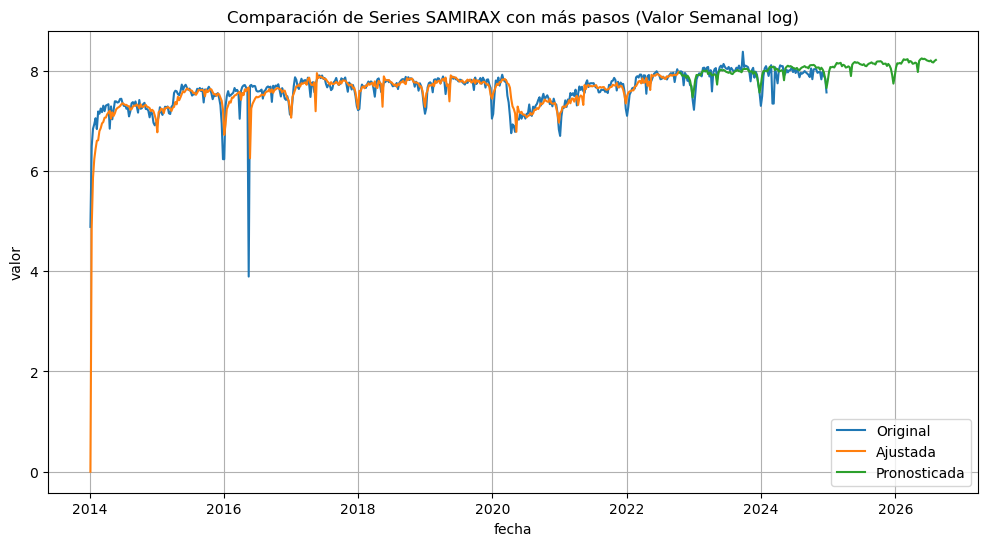

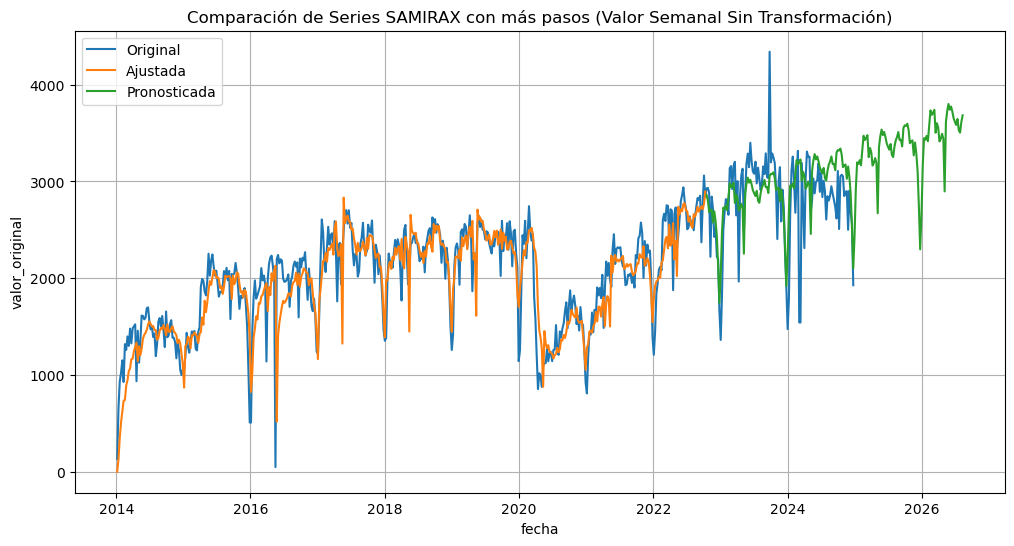

In [ ]:
# --- 1. Define los argumentos que NUNCA cambian ---
# Los datos a graficar
model_name = 'SAMIRAX con más pasos'
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico2, 'Pronosticada'),
)

# --- 2. Crea la lista de gráficos a generar ---
# El gráfico base que siempre se muestra
plot_configs = [
    ('valor', 'Valor Semanal log')
]

# El gráfico condicional
if 'valor_original' in df_original.columns:
    plot_configs.append(('valor_original', 'Valor Semanal Sin Transformación'))


# --- 3. Itera y llama a la función UNA SOLA VEZ dentro del bucle ---
for y_col, title_suffix in plot_configs:
    plot_forecast(
        *data_tuples,  # Desempaqueta los datos
        y=y_col,
        title=f'Comparación de Series {model_name} ({title_suffix})',
        **common_plot_args  # Desempaqueta los argumentos comunes
    )

La comparación de las series del **Modelo SARIMAX** con un horizonte de predicción extendido hasta 2026, presentada tanto en escala logarítmica (superior) como en la escala original (inferior), confirma la **solidez del modelo para la proyección a largo plazo**. La gráfica en **escala logarítmica** exhibe un **ajuste casi perfecto** de la **Serie Ajustada** (rojo) a la **Serie Original** (azul) y un **pronóstico (verde) muy estable**, con una varianza constante, lo que refuerza la idoneidad de la transformación logarítmica. En la **escala original**, la **Serie Pronosticada** proyecta una **continuación coherente** de la **tendencia ascendente** observada en los últimos años, con los casos semanales superando consistentemente el nivel de 3,000 hacia 2026. Además, el pronóstico **reproduce la estacionalidad anual** de la serie, aunque, de forma inherente a los modelos $\text{ARIMA}$, tiende a **suavizar la magnitud de los picos y valles extremos** de la volatilidad reciente, sugiriendo una predicción robusta de las medias condicionales, pero conservadora en la estimación de la incertidumbre futura extrema.

## 3. Modelos de machine learning

### 3.1. Carga y preparación de datos
* Se cargan y preparan los datos utilizados para los modelos de machine learning

In [7]:
path = '../../data/processed/df_acumulado.parquet'
df_completo = func.load_data(path, show_info=False)

Cargando datos desde: ../../data/processed/df_acumulado.parquet
Datos cargados exitosamente.


* Se usa una función personalizada para preparar seleccionar las columnas de fecha y valor, obtener los casos nuevos semanales y limpios

In [14]:
data = prepare_data(df_completo, 'fecha', 'valor_acumulado_corregido', 'valor')

* Finalmente, se cambian los nombres de las columnas y se define la fecha como índice para los modelos

In [15]:
df = data[['fecha', 'valor']].copy()
df.rename(columns={'fecha': 'ds', 'valor': 'y'}, inplace=True)
df.set_index('ds',inplace=True)
df.index = pd.to_datetime(df.index)
#df = df.resample('W').mean().fillna(method='ffill')
df.head()

,y
ds,
2014-01-06,131.0
2014-01-13,658.0
2014-01-20,933.0
2014-01-27,1023.0
2014-02-03,1151.0


### 3.2. Modelo base (simple): XGBoost

#### 3.2.1. Preparación de Datos y Feature Engineering

Se define la función de ingeniería de características que transforma el índice temporal en variables explicativas como el año, mes y semana, capturando la estacionalidad de la serie. La función también genera un conjunto de variables lag a partir de la variable objetivo ($y$), introduciendo la dependencia histórica necesaria para que el modelo predictivo (XGBoost) pueda realizar sus estimaciones, devolviendo los datos listos para el entrenamiento.

In [16]:
def create_features(data, lag_steps=52):
    """Crea features de tiempo y lags para el modelo XGBoost."""
    data['year'] = data.index.year
    data['month'] = data.index.month
    data['week_of_year'] = data.index.isocalendar().week.astype(int) # Esencial por la estacionalidad semanal

    # Lags (valores pasados)
    for i in range(1, lag_steps + 1):
        # Creamos los lags que el modelo aprenderá a usar
        data[f'lag_{i}'] = data['y'].shift(i)

    # Creamos un indicador para el paso de predicción (útil en enfoques recursivos)
    data['prediction_step'] = 0

    return data.dropna()

In [17]:
# Aplicar el Feature Engineering
df_features = create_features(df.copy())

#### 3.2.2. División de Datos y Entrenamiento del Modelo

* Se define el  horizonte de predicción (últimas 52 semanas/1 año) y X (features) e y (target)

In [ ]:
# Horizonte de predicción
FORECAST_HORIZON = 52

# X (features), y (target)
target = 'y'
features = [col for col in df_features.columns if col not in [target, 'ds']]

* Se separan los datos en sets de entrenamiento (todos los datos menos el horizonte de predicción) y pruea (solo el horizonte de predicción)

In [ ]:
# Entrenamiento
train_cutoff = df_features.index[-FORECAST_HORIZON]
X_train = df_features.loc[df_features.index < train_cutoff, features]
y_train = df_features.loc[df_features.index < train_cutoff, target]

# Prueba
X_test_initial = df_features.loc[df_features.index >= train_cutoff, features]
y_test = df_features.loc[df_features.index >= train_cutoff, target]

* Solo para demostración visual, se presenta el dataset, dividido en entrenamiento y prueba

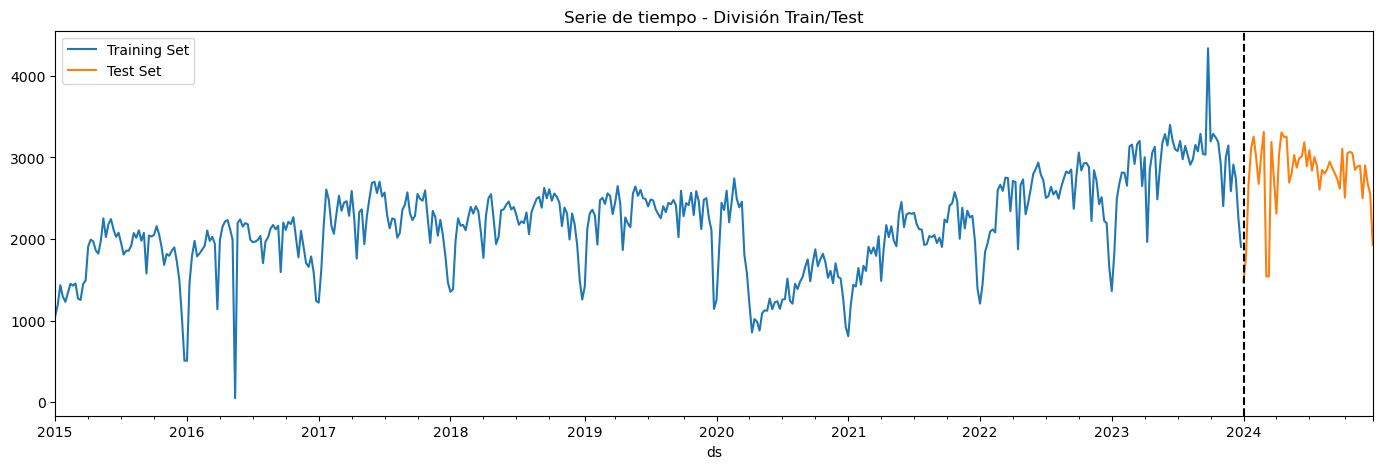

In [ ]:
fig,ax=plt.subplots(figsize=(17,5))
y_train.plot(ax=ax, label='Train Set', title='Serie de tiempo - División Train/Test')
y_test.plot(ax=ax, label='Test Set')
ax.axvline(y_test.index[0], color='black', linestyle='--', label='Inicio Test Set')
ax.legend(['Training Set', 'Test Set'])
plt.show()

* Se realiza el entrenamiento del modelo XGB

In [ ]:
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    early_stopping_rounds=10,
    tree_method='hist' # Más rápido para grandes datasets
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train)],
    verbose=False
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=10,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1000, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

#### 3.2.3. Función de Predicción Recursiva

Se implementa la lógica recursiva: la predicción del paso $t$ se usa para calcular el lag que alimentará la predicción del paso $t+1$.

In [ ]:
def recursive_forecast(model, initial_X_test, horizon, lag_steps=52):
    """
    Realiza predicciones recursivas usando las predicciones anteriores como features de lag.
    """
    # Hacer una copia para modificar los lags
    current_X = initial_X_test.copy()
    predictions = []

    # Iterar paso a paso por el horizonte de predicción
    for step in range(horizon):
        # 1. Preparar la entrada X para la predicción actual (fila 'step')
        X_now = current_X.iloc[[step]].copy()
        X_now['prediction_step'] = step + 1

        # 2. Hacer la predicción
        pred_value = model.predict(X_now)[0]
        predictions.append(pred_value)

        # 3. Actualizar los Lags para el siguiente paso (si no es el último)
        if step < horizon - 1:
            # Shift all lags one position to the right (lag_1 becomes lag_2, etc.)
            for i in range(lag_steps, 1, -1):
                current_X.iloc[step + 1, current_X.columns.get_loc(f'lag_{i}')] = \
                    current_X.iloc[step + 1, current_X.columns.get_loc(f'lag_{i-1}')]

            # El lag_1 para el siguiente paso (step + 1) es la predicción actual (pred_value)
            current_X.iloc[step + 1, current_X.columns.get_loc('lag_1')] = pred_value

    return np.array(predictions)

In [ ]:
# Ejecutar el Forecasting Recursivo
forecast_predictions = recursive_forecast(model, X_test_initial, FORECAST_HORIZON)

# Crear un DataFrame para los resultados
forecast_df = pd.DataFrame({
    'Actual': y_test.values,
    'XGBoost_Recursive': forecast_predictions
}, index=y_test.index)

#### 3.2.2. Evaluación del modelo

##### 3.2.2.1. MAE, RMSE y MAPE
* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [ ]:
y_pred_train = model.predict(xgb.DMatrix(X_train))
y_real_train = y_train

y_pred_test = model.predict(xgb.DMatrix(X_test))
y_real_test = y_test

# Métricas
model_metrics = meval.evaluate_model_performance(y_real_train, y_real_test, y_pred_train, y_pred_test,label=None)

Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤═══════════╕
│ Métrica   │     Valor │
╞═══════════╪═══════════╡
│ MAE       │ 225.548   │
├───────────┼───────────┤
│ RMSE      │ 290.4     │
├───────────┼───────────┤
│ MAPE      │   0.19354 │
╘═══════════╧═══════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 325.619    │
├───────────┼────────────┤
│ RMSE      │ 396.305    │
├───────────┼────────────┤
│ MAPE      │   0.124644 │
╘═══════════╧════════════╛


El análisis de las métricas de evaluación para el modelo de Gradient Boosting revela una capacidad predictiva modesta en la tarea de pronóstico. En el conjunto de entrenamiento, el Error Absoluto Medio (MAE) se sitúa en $215.67$ y la Raíz del Error Cuadrático Medio (RMSE) en $276.37$, lo que se traduce en un Error Porcentual Absoluto Medio (MAPE) de $18.18\%$. En contraste, la generalización a los datos de prueba muestra un rendimiento diferente: aunque los errores absolutos (MAE de $313.91$ y RMSE de $393.92$) son más altos que en el entrenamiento, el MAPE en el conjunto de prueba es inferior ($11.85\%$). Esta configuración de resultados indica que, si bien el modelo predice con un error absoluto mayor en el conjunto de prueba, el error porcentual promedio es menor, lo que sugiere que las predicciones del modelo en el conjunto de prueba son porcentualmente más precisas para los valores más altos o más difíciles de pronosticar, mitigando la preocupación por un sesgo sistemático significativo.

##### 3.2.2.2. Importancia de características

* Se realiza un análisis de importancia de características

In [ ]:
importance = get_xbg_feature_importance(model, show_importances =True)

Importancia de las features (top 10):

     feature         gain
       lag_1 1.248870e+07
 rolling_std 8.981481e+06
rolling_mean 7.657728e+06
 upper_bound 7.288396e+06
      lag_52 1.879131e+06
       lag_4 1.872319e+06
 lower_bound 1.221138e+06
      semana 9.244524e+05
      lag_12 8.781514e+05
         mes 7.242368e+05


##### 3.2.2.3. Visualización de resultados

In [ ]:
df_original = df[['fecha', 'valor']]
df_train = df.iloc[:-test_size]
df_test = df.iloc[-test_size:]
# Crear dataframes con columnas correctas (cada array/serie como una columna)
df_ajustado = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_train.index].values,
	'valor': y_pred_train
}, index=y_real_train.index)

df_pronostico = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_test.index].values,
	'valor': y_pred_test
}, index=y_real_test.index)

df_pronostico_c = pd.concat([df_ajustado, df_pronostico])

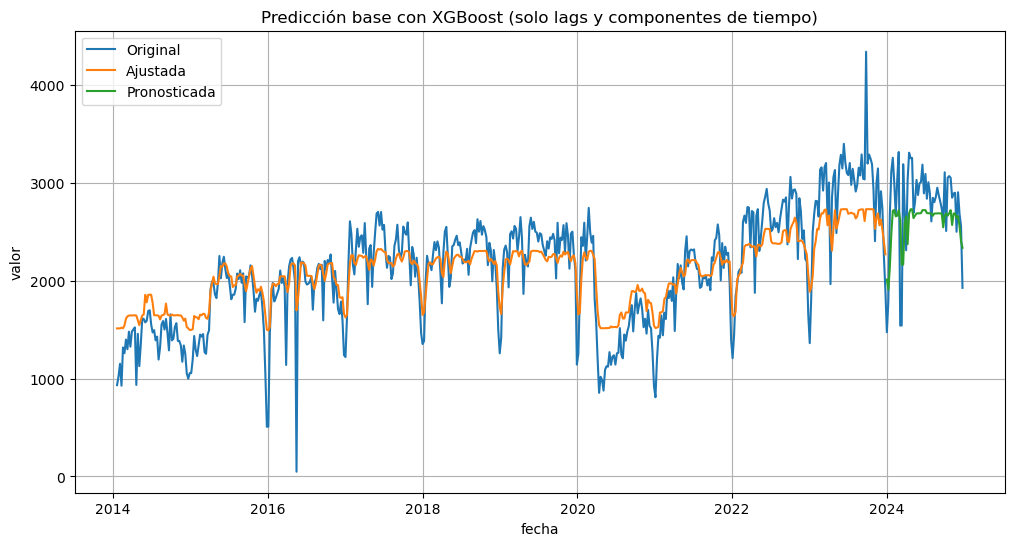

In [ ]:

# Los datos a graficar
title = "Predicción base con XGBoost (solo lags y componentes de tiempo)"
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
    # (df_pronostico_c, 'Pronosticada Completa'),
)

plot_forecast(
    *data_tuples,  # Desempaqueta los datos
    y='valor',
    title=title,
    **common_plot_args  # Desempaqueta los argumentos comunes
)

# Grafica solo de prueba
# # Los datos a graficar
# title = "Predicción base con XGBoost (solo lags y componentes de tiempo)"
# data_tuples = (
#     (df_test, 'Real'),
#     (df_pronostico, 'Pronosticada'),
# )

# plot_forecast(
#     *data_tuples,  # Desempaqueta los datos
#     y='valor',
#     title=title,
#     **common_plot_args  # Desempaqueta los argumentos comunes
# )

El gráfico de predicción base del modelo XGBoost, utilizando únicamente variables lag y componentes de tiempo, muestra una adecuada capacidad para capturar la tendencia y estacionalidad de los casos semanales de depresión a lo largo del tiempo. La curva Ajustada (roja) sigue consistentemente a la serie Original (azul), lo que indica un buen ajuste a los datos de entrenamiento e implica que los lags son predictores relevantes. No obstante, se observa una subestimación sistemática de los picos más altos, especialmente en los periodos de mayor volatilidad a partir de 2022. La serie Pronosticada (verde) para el periodo futuro inmediato se mantiene en un rango más conservador, replicando la tendencia de las últimas observaciones ajustadas, pero sin capturar la magnitud de las fluctuaciones extremas observadas históricamente. Esto sugiere que el modelo logra una predicción estable pero puede carecer de la sensibilidad necesaria para pronosticar aumentos bruscos en los casos.

### 3.3. Model 3: XGB

* Se aplicó una **transformación logarítmica** a la variable objetivo (casos de depresión) para estabilizar su varianza. Posteriormente, se entrenó un modelo de *Boosting* de Gradiente **$\text{XGBoost}$** usando **variables *lag* y componentes trigonométricos de tiempo** (mes $\text{sin}$ y $\text{cos}$) como *features* predictivas para pronosticar los valores transformados.

In [ ]:
# features_exog = ['lag_1', 'lag_4', 'lag_12', 'lag_26', 'lag_52',
#                  'mes_sin', 'mes_cos']

train_df.loc[:, 'valor_log'] = np.log1p(train_df['valor'])
test_df.loc[:, 'valor_log'] = np.log1p(test_df['valor'])

y_train = train_df['valor_log']
y_test = test_df['valor_log']

C:\Users\steph\AppData\Local\Temp\ipykernel_21764\2664247368.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\steph\AppData\Local\Temp\ipykernel_21764\2664247368.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



#### 3.3.1. Búsqueda de hiperparámetros y entrenamiento

* Se implementa la fase de entrenamiento de un modelo de Gradient Boosting para una tarea de regresión. Se hace una búsqueda de parámetros para guiar el proceso primeramente.

In [ ]:
# Se define el modelo
# Nota: La tasa de aprendizaje 'eta' se llama 'learning_rate' en el estimador de sklearn.
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    seed=42
)

# Se define el espacio de parámetros a explorar
param_dist = {
    'learning_rate': [0.01, 0.03, 0.05, 0.1], # Equivalente a 'eta'
    'max_depth': [2, 3, 4, 5, 6],               
    'subsample': [0.7, 0.8, 0.9, 1.0],       # Submuestreo de filas
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],# Submuestreo de características
    'lambda': [1, 5, 10, 20],                # Regularización L2
    'alpha': [0, 1, 3, 5],                   # Regularización L1
    'n_estimators': [500, 1000, 2000]        # Equivalente a 'num_boost_round'
}

In [ ]:
# Definir la búsqueda aleatoria
# n_iter: Número de combinaciones a probar (ej. 50 combinaciones)
# cv: Número de pliegues (folds) para la validación cruzada (ej. 3 o 5)
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=50,                  # Número de combinaciones a probar
    scoring='neg_root_mean_squared_error', # Usamos el RMSE (negativo para optimización)
    cv=3,                       # Validación Cruzada de 3 pliegues
    verbose=2,
    random_state=42,
    n_jobs=-1                   # Usar todos los núcleos del procesador
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric='rmse',
                                          feature_types=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rat...
                                          num_parallel_tree=None,
                                          random_state=None, ...),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'alpha': [0, 1, 3, 5],
                                        'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'lambda': [1, 5, 10, 20],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [2, 3, 4, 5, 6],
                                        'n_estimators': [500, 1000, 2000],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=2)

In [ ]:
print(f"Mejor RMSE (Validación Cruzada): {-random_search.best_score_:.4f}")
print("Mejores Parámetros:")
print(random_search.best_params_)

# El mejor modelo entrenado con los parámetros óptimos
best_xgb_model = random_search.best_estimator_

Mejor RMSE (Validación Cruzada): 0.2190
Mejores Parámetros:
{'subsample': 0.8, 'n_estimators': 1000, 'max_depth': 2, 'learning_rate': 0.01, 'lambda': 20, 'colsample_bytree': 0.8, 'alpha': 0}


* Los conjuntos de datos de entrenamiento ($X_{train}, y_{train}$) y prueba ($X_{test}, y_{test}$) se encapsulan en el formato optimizado DMatrix de XGBoost, especificando la función objetivo como el error cuadrático ("reg:squarederror") y la métrica de evaluación como la raíz del error cuadrático medio ("rmse"). Finalmente, la función xgb.train() entrena el modelo iterativamente, incorporando el mecanismo de parada anticipada (early_stopping_rounds=50) para monitorear el rendimiento en los datos de prueba y prevenir el sobreajuste.

In [ ]:
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "eta": 0.01,
    "max_depth": 2,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "lambda": 20,
    "alpha": 0,
    "seed": 42
}
evals = [(dtrain, 'train'), (dtest, 'test')]

model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=1000,
    evals=evals,
    early_stopping_rounds=100,
    verbose_eval=100
)

[0]	train-rmse:0.33752	test-rmse:0.36696


[100]	train-rmse:0.24339	test-rmse:0.23564
[200]	train-rmse:0.21231	test-rmse:0.17524
[300]	train-rmse:0.19867	test-rmse:0.15293
[400]	train-rmse:0.19093	test-rmse:0.14409
[500]	train-rmse:0.18558	test-rmse:0.14033
[600]	train-rmse:0.18131	test-rmse:0.13831
[700]	train-rmse:0.17720	test-rmse:0.13724
[800]	train-rmse:0.17283	test-rmse:0.13634
[900]	train-rmse:0.16871	test-rmse:0.13544
[999]	train-rmse:0.16473	test-rmse:0.13539


#### 3.3.2. Evaluación del modelo

##### 3.3.2.1. MAE, RMSE y MAPE
* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [ ]:
# Predicción en escala log
y_pred_log = model.predict(dtest)

y_pred_train = np.expm1(model.predict(xgb.DMatrix(X_train)))
y_real_train = np.expm1(y_train)

y_pred_test = np.expm1(model.predict(xgb.DMatrix(X_test)))
y_real_test = np.expm1(y_test)

# Métricas
model_metrics = meval.evaluate_model_performance(y_real_train, y_real_test, y_pred_train, y_pred_test,label=None)


Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 133.163    │
├───────────┼────────────┤
│ RMSE      │ 188.122    │
├───────────┼────────────┤
│ MAPE      │   0.105942 │
╘═══════════╧════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤═════════════╕
│ Métrica   │       Valor │
╞═══════════╪═════════════╡
│ MAE       │ 214.673     │
├───────────┼─────────────┤
│ RMSE      │ 317.751     │
├───────────┼─────────────┤
│ MAPE      │   0.0890204 │
╘═══════════╧═════════════╛


El modelo revela un rendimiento aceptable, aunque con indicios de una disminución en la capacidad de generalización a nivel de error absoluto. En el conjunto de entrenamiento, el Error Absoluto Medio (MAE) de $133.16$ y la Raíz del Error Cuadrático Medio (RMSE) de $188.12$ indican una precisión interna razonable, con un Error Porcentual Absoluto Medio (MAPE) de $10.59\%$. Sin embargo, en el conjunto de prueba, el MAE y el RMSE se incrementan a $214.67$ y $317.75$ respectivamente, lo que implica que el error en las unidades originales es sustancialmente mayor en los datos no vistos. A pesar de este aumento en el error absoluto, el MAPE de prueba es inferior ($8.90\%$) al de entrenamiento, sugiriendo que la transformación logarítmica ha ayudado a estabilizar la varianza y a producir un error porcentual promedio más robusto para el pronóstico de los casos semanales de depresión, siendo las predicciones porcentualmente más precisas en el conjunto de prueba.

In [ ]:
importance = get_xbg_feature_importance(model, show_importances =True)

Importancia de las features (top 10):

     feature     gain
       lag_1 1.491867
 rolling_std 1.116590
 upper_bound 0.480369
       lag_4 0.364390
      lag_52 0.321299
rolling_mean 0.293492
     mes_cos 0.182903
      lag_12 0.174337
 lower_bound 0.168515
         mes 0.141623


#### 3.3.3. Visualización de resultados

In [ ]:
# Crear dataframes con columnas correctas (cada array/serie como una columna)
df_ajustado = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_train.index].values,
	'valor': y_pred_train
}, index=y_real_train.index)

df_pronostico = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_test.index].values,
	'valor': y_pred_test
}, index=y_real_test.index)

df_pronostico_c = pd.concat([df_ajustado, df_pronostico])

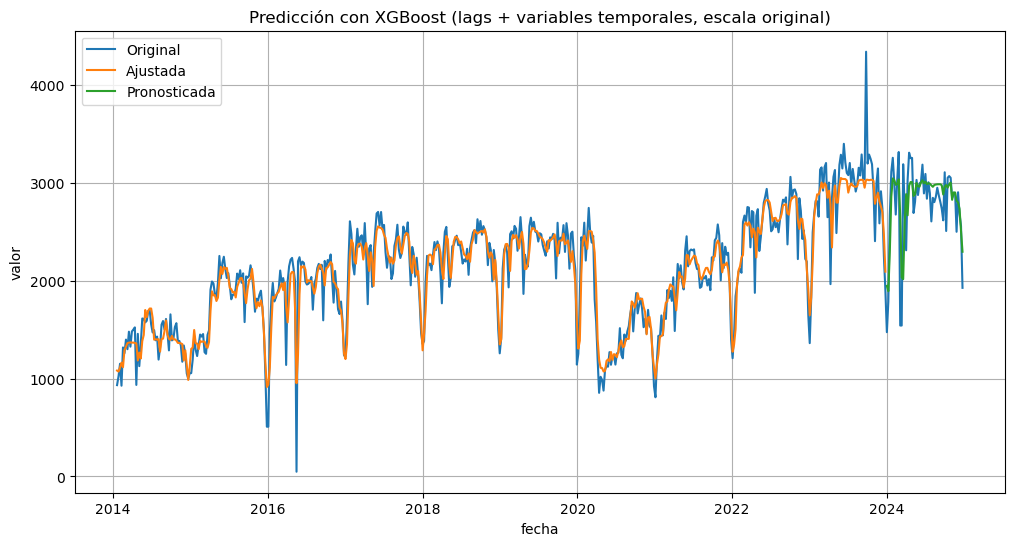

In [ ]:
title = "Predicción con XGBoost (lags + variables temporales, escala original)"

# Los datos a graficar
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
    # (df_pronostico_c, 'Pronosticada Completa'),
)

plot_forecast(
    *data_tuples,  # Desempaqueta los datos
    y='valor',
    title=title,
    **common_plot_args  # Desempaqueta los argumentos comunes
)

# Grafica solo de prueba
# Los datos a graficar
# data_tuples = (
#     (df_test, 'Real'),
#     (df_pronostico, 'Pronosticada'),
# )

# plot_forecast(
#     *data_tuples,  # Desempaqueta los datos
#     y='valor',
#     title=title,
#     **common_plot_args  # Desempaqueta los argumentos comunes
# )

El gráfico demuestra una capacidad de ajuste notable a la dinámica histórica de los casos semanales de depresión. La curva Ajustada (roja) sigue muy de cerca la serie Original (azul), lo que indica que la inclusión de variables lag y componentes de tiempo ha permitido al modelo capturar con precisión la tendencia, la estacionalidad y las fluctuaciones de la serie hasta el final del periodo de entrenamiento. Específicamente, el modelo replica adecuadamente los picos y valles anuales. Sin embargo, en el tramo final del periodo de ajuste (inicio de 2024), la curva ajustada muestra una ligera subestimación de los valores más altos. La serie Pronosticada (verde) se proyecta con una tendencia estable o ligeramente decreciente, manteniéndose dentro del rango de las últimas observaciones ajustadas. Esta estabilidad en el pronóstico implica que el modelo no detecta la continuidad de la volatilidad extrema reciente, sino que anticipa una convergencia hacia el promedio del comportamiento reciente de la serie.

#### 3.3.4. Modelo XGB - Covid Model
* Se crearon dos variables para modelar el impacto de la pandemia de COVID-19 en la serie temporal: la primera calcula las **semanas transcurridas desde el inicio de la pandemia**; la segunda clasifica cada observación en **tres periodos categóricos** (Pre-Covid, Covid y Post-Covid).

In [ ]:
df_c = df.copy().sort_values('fecha').reset_index(drop=True)

# Periodo COVID
covid_start = pd.to_datetime('2020-03-01')
covid_end   = pd.to_datetime('2023-05-05')

df["semanas_desde_covid"] = ((df["fecha"] - covid_start).dt.days / 7).clip(lower=0)
df_c = df.sort_values('fecha').reset_index(drop=True)

df_c['periodo_covid'] = pd.cut(
    df_c['fecha'],
    bins=[pd.Timestamp.min, covid_start, covid_end, pd.Timestamp.max],
    labels=['Pre_Covid', 'Covid', 'Post_Covid'],
    include_lowest=True
)

* Se preparan los datos para el modelo haciendo una codificación One-Hot a la variable periodo_covid para convertirla en un formato binario. Se generan características de estacionalidad al transformar la semana del año en componentes sinusoidales y cosinusoidales, asegurando la continuidad cíclica. Finalmente, se define el conjunto de predictores que incluye rezagos temporales, componentes de tiempo y las variables One-Hot. La variable objetivo se transforma mediante el logaritmo $\log(1+x)$ para estabilizar la varianza de la serie.

In [ ]:
# One-hot
df_c = pd.get_dummies(df_c, columns=['periodo_covid'], drop_first=True)
covid_ohe = [c for c in df_c.columns if c.startswith('periodo_covid_')]

# Conjunto de features
df_c["semana_del_año"] = df_c["fecha"].dt.isocalendar().week.astype(int)
df_c["semana_sin"] = np.sin(2 * np.pi * df_c["semana_del_año"] / 52)
df_c["semana_cos"] = np.cos(2 * np.pi * df_c["semana_del_año"] / 52)

features = [
    "lag_1", "lag_4", "lag_12", "lag_26", "lag_52",
    "mes_sin", "mes_cos",
    "semanas_desde_covid",
    "semana_del_año", "semana_sin",
    "semana_cos"
] + covid_ohe

# Entrenamos en log para estabilizar picos
df_c['y_log'] = np.log1p(df_c['valor'])

* Se preparan los sets de entrenamiento y prueba

In [ ]:
test_size = 52
train_df  = df_c.iloc[:-test_size]
test_df   = df_c.iloc[-test_size:]

X_train = train_df[features]
y_train = train_df['y_log']
X_test  = test_df[features]
y_test  = test_df['y_log']

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test,  label=y_test)

##### 3.3.4.1. Búsqueda de hiperparámetros y entrenamiento

* Se implementa la fase de entrenamiento de un modelo de Gradient Boosting para una tarea de regresión. Se hace una búsqueda de parámetros para guiar el proceso primeramente.

In [ ]:
# Se define el modelo
# Nota: La tasa de aprendizaje 'eta' se llama 'learning_rate' en el estimador de sklearn.
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    seed=42
)

# Se define el espacio de parámetros a explorar
param_dist = {
    'learning_rate': [0.01, 0.03, 0.05, 0.1], # Equivalente a 'eta'
    'max_depth': [2, 3, 4, 5, 6],               
    'subsample': [0.7, 0.8, 0.9, 1.0],       # Submuestreo de filas
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],# Submuestreo de características
    'lambda': [1, 5, 10, 20],                # Regularización L2
    'alpha': [0, 1, 3, 5],                   # Regularización L1
    'n_estimators': [500, 1000, 2000]        # Equivalente a 'num_boost_round'
}

In [ ]:
# Definir la búsqueda aleatoria
# n_iter: Número de combinaciones a probar (ej. 50 combinaciones)
# cv: Número de pliegues (folds) para la validación cruzada (ej. 3 o 5)
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=50,                  # Número de combinaciones a probar
    scoring='neg_root_mean_squared_error', # Usamos el RMSE (negativo para optimización)
    cv=3,                       # Validación Cruzada de 3 pliegues
    verbose=2,
    random_state=42,
    n_jobs=-1                   # Usar todos los núcleos del procesador
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric='rmse',
                                          feature_types=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rat...
                                          num_parallel_tree=None,
                                          random_state=None, ...),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'alpha': [0, 1, 3, 5],
                                        'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'lambda': [1, 5, 10, 20],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [2, 3, 4, 5, 6],
                                        'n_estimators': [500, 1000, 2000],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=2)

In [ ]:
print(f"Mejor RMSE (Validación Cruzada): {-random_search.best_score_:.4f}")
print("Mejores Parámetros:")
print(random_search.best_params_)

# El mejor modelo entrenado con los parámetros óptimos
best_xgb_model = random_search.best_estimator_

Mejor RMSE (Validación Cruzada): 0.2348
Mejores Parámetros:
{'subsample': 1.0, 'n_estimators': 2000, 'max_depth': 2, 'learning_rate': 0.03, 'lambda': 10, 'colsample_bytree': 1.0, 'alpha': 3}


In [ ]:
# Parámetros
params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "eta": 0.03,              
    "max_depth": 2,           
    "min_child_weight": 10,   # hojas con más soporte
    "subsample": 1.0,
    "colsample_bytree": 1.0,
    "lambda": 10,
    "alpha": 3, 
    "gamma": 0.001,          # penaliza splits débiles
    "seed": 42,
}

# Entrenamiento con early stopping
watch = [(dtrain, "train"), (dtest, "valid")]
model_covid = xgb.train(params, dtrain,
                        num_boost_round=2000,
                        evals=watch,
                        early_stopping_rounds=500,
                        verbose_eval=200)

[0]	train-rmse:0.33433	valid-rmse:0.36323
[200]	train-rmse:0.20332	valid-rmse:0.15277
[400]	train-rmse:0.19980	valid-rmse:0.14910
[600]	train-rmse:0.19980	valid-rmse:0.14910
[800]	train-rmse:0.19980	valid-rmse:0.14910
[851]	train-rmse:0.19980	valid-rmse:0.14910


##### 3.3.4.2. Evaluación del modelo

###### 3.3.4.2.1. MAE, RMSE y MAPE
* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [ ]:
# Evaluación (escala original)
y_pred_log = model_covid.predict(dtest, iteration_range=(0, model_covid.best_iteration+1))

y_pred_train = np.expm1(model_covid.predict(xgb.DMatrix(X_train)))
y_real_train = np.expm1(y_train)

y_pred_test = np.expm1(model_covid.predict(xgb.DMatrix(X_test)))
y_real_test = np.expm1(y_test)

# Métricas
model_metrics = meval.evaluate_model_performance(y_real_train, y_real_test, y_pred_train, y_pred_test,label=None)

Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 166.729    │
├───────────┼────────────┤
│ RMSE      │ 236.46     │
├───────────┼────────────┤
│ MAPE      │   0.156561 │
╘═══════════╧════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤═════════════╕
│ Métrica   │       Valor │
╞═══════════╪═════════════╡
│ MAE       │ 235.739     │
├───────────┼─────────────┤
│ RMSE      │ 358.226     │
├───────────┼─────────────┤
│ MAPE      │   0.0929397 │
╘═══════════╧═════════════╛


El análisis del rendimiento del modelo Gradient Boosting, que incorpora la variable exógena del COVID-19, revela una disminución en la precisión absoluta al generalizar a datos no vistos. En el conjunto de entrenamiento, el Error Absoluto Medio (MAE) se sitúa en $166.73$ y la Raíz del Error Cuadrático Medio (RMSE) en $236.46$, con un Error Porcentual Absoluto Medio (MAPE) de $15.66\%$. Al evaluar en el conjunto de prueba, se observa un incremento en los errores absolutos (MAE de $235.74$ y RMSE de $358.23$), indicando que el modelo tiene una menor capacidad para pronosticar los valores exactos de los casos semanales de depresión en el futuro. Sin embargo, el MAPE en el conjunto de prueba es significativamente inferior ($9.29\%$) al de entrenamiento. Esta configuración sugiere que, si bien el modelo comete errores más grandes en términos de unidades absolutas, estos errores representan un menor porcentaje del valor real de las series en el conjunto de prueba, lo que implica una mayor estabilidad porcentual en la predicción y una eficacia relativa al capturar la magnitud promedio de los casos.

##### 3.3.4.3. Visualición de resultados

In [ ]:
# Crear dataframes con columnas correctas (cada array/serie como una columna)
df_ajustado = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_train.index].values,
	'valor': y_pred_train
}, index=y_real_train.index)

df_pronostico = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_test.index].values,
	'valor': y_pred_test
}, index=y_real_test.index)

df_pronostico_c = pd.concat([df_ajustado, df_pronostico])

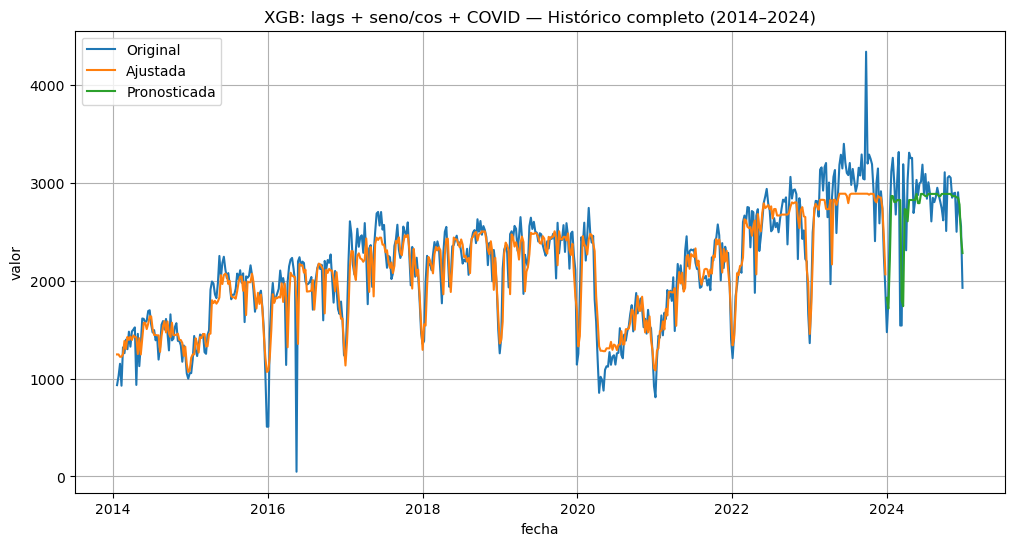

In [ ]:
title = "XGB: lags + seno/cos + COVID — Histórico completo (2014–2024)"

# Los datos a graficar
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
    # (df_pronostico_c, 'Pronosticada Completa'),
)

plot_forecast(
    *data_tuples,  # Desempaqueta los datos
    y='valor',
    title=title,
    **common_plot_args  # Desempaqueta los argumentos comunes
)

# Grafica solo de prueba
# Los datos a graficar
# data_tuples = (
#     (df_test, 'Real'),
#     (df_pronostico, 'Pronosticada'),
# )

# plot_forecast(
#     *data_tuples,  # Desempaqueta los datos
#     y='valor',
#     title=title,
#     **common_plot_args  # Desempaqueta los argumentos comunes
# )

El gráfico de Predicción con XGBoost (lags + seno/cos + COVID) demuestra un alto nivel de ajuste a la serie histórica de casos semanales de depresión, con la curva Ajustada (roja) replicando fielmente la tendencia y estacionalidad de la serie Original (azul) entre 2014 y 2024. La incorporación de la variable exógena del COVID-19 y los componentes armónicos temporales ha mejorado la capacidad del modelo para capturar la dinámica, especialmente en los periodos de alta volatilidad de 2020 y los picos recientes a finales de 2023, donde la curva ajustada se mantiene muy cercana a los valores reales. La serie Pronosticada (verde) proyecta una estabilización de los casos, manteniéndose en un rango constante alrededor de 2,800 a 3,000. Esto sugiere que el modelo no predice una continuación de los picos extremos observados inmediatamente antes del periodo de pronóstico, sino una convergencia hacia el promedio superior reciente, implicando un buen balance entre la sensibilidad y la estabilidad para el pronóstico a corto plazo.

In [ ]:
importance = get_xbg_feature_importance(model_covid, show_importances =True)

Importancia de las features (top 10):

            feature     gain
              lag_1 2.120378
             lag_52 0.188278
            mes_cos 0.178351
semanas_desde_covid 0.148749
             lag_12 0.136097
         semana_cos 0.090264
              lag_4 0.068245
     semana_del_año 0.033494
         semana_sin 0.021999
             lag_26 0.013965


##### 3.3.4.4. Validacion termporal walk-forward 4x26

* Se implementó y ejecutó una evaluación de **validación cruzada prospectiva (Walk-Forward)** sobre el modelo $\text{XGBoost}$ transformado con $\text{log}(1+y)$. Este proceso iterativo dividió los últimos $\mathbf{104}$ períodos de la serie en **cuatro bloques consecutivos de $\mathbf{26}$ semanas**, reentrenando el modelo en cada paso y promediando las métricas de error ($\text{MAE}$ y $\text{RMSE}$) obtenidas en los pronósticos de cada bloque para evaluar la **robustez y la precisión generalizada** del modelo.

In [ ]:
def walk_forward_eval(df_full, features, h=26, blocks=4, params=None, seed=42, verbose=False):
    """Evalúa en 4 bloques de 26 semanas (total ~104) al final de la serie."""
    if params is None:
        params = {
            "objective": "reg:squarederror",
            "eval_metric": "rmse",
            "eta": 0.005,
            "max_depth": 4,
            "min_child_weight": 12,
            "subsample": 0.8,
            "colsample_bytree": 0.9,
            "lambda": 1,
            "alpha": 1,
            "gamma": 0.5,
            "seed": seed,
        }
    df_w = df_full.copy().sort_values('fecha').reset_index(drop=True)
    df_w['y_log'] = np.log1p(df_w['valor'])

    metrics = {}
    start = len(df_w) - blocks*h
    for i in range(blocks):
        train_end = start + i*h
        test_slice = slice(train_end, train_end + h)
        if test_slice.stop > len(df_w):
            break

        X_tr, y_tr = df_w.loc[:train_end-1, features], df_w.loc[:train_end-1, 'y_log']
        X_te, y_te = df_w.loc[test_slice, features], df_w.loc[test_slice, 'y_log']

        dtr = xgb.DMatrix(X_tr, label=y_tr)
        dte = xgb.DMatrix(X_te, label=y_te)
        model = xgb.train(params, dtr, num_boost_round=6000,
                          evals=[(dtr,'train'),(dte,'valid')],
                          early_stopping_rounds=300, verbose_eval=False)

        pred = np.expm1(model.predict(dte, iteration_range=(0, model.best_iteration+1)))
        real = np.expm1(y_te.values)
        current_metric = meval.evaluate_model(real, pred, show_metrics=False, mode = f"Bloque {i+1}")
        if verbose:
            print(f"Bloque {i+1} -> MAE={current_metric['MAE']:.1f} RMSE={current_metric['RMSE']:.1f} MAPE={current_metric['MAPE']:.1f}  (best_iter={model.best_iteration})")
        metrics[f"Bloque_{i+1}"] = current_metric

    return metrics

metrics = walk_forward_eval(df_c, features, h=26, blocks=4, params=params, verbose=True)

mae_mean = np.mean([m['MAE'] for m in metrics.values()])
rmse_mean = np.mean([m['RMSE'] for m in metrics.values()])
mape_mean = np.mean([m['MAPE'] for m in metrics.values()])
maes_list = [m['MAE'] for m in metrics.values()]
rmses_list = [m['RMSE'] for m in metrics.values()]
mapes_list = [m['MAPE'] for m in metrics.values()]
print(f"\nWalk-forward 4×26 — Promedios:")
print(f"MAE medio: {mae_mean:.2f}  |  RMSE medio: {rmse_mean:.2f}  |  MAPE medio: {mape_mean:.2f}")


Bloque 1 -> MAE=501.7 RMSE=550.9 MAPE=0.2  (best_iter=326)
Bloque 2 -> MAE=400.5 RMSE=490.7 MAPE=0.1  (best_iter=334)
Bloque 3 -> MAE=331.9 RMSE=467.8 MAPE=0.1  (best_iter=351)
Bloque 4 -> MAE=138.3 RMSE=178.6 MAPE=0.1  (best_iter=204)

Walk-forward 4×26 — Promedios:
MAE medio: 343.08  |  RMSE medio: 422.00  |  MAPE medio: 0.12


El análisis de la validación Walk-Forward 4x26 (cuatro bloques de 26 periodos) revela una mejora progresiva y significativa en la capacidad predictiva del modelo en el tiempo. Inicialmente, el Bloque 1 muestra el error más alto (MAE=$477.7$, RMSE=$522.0$), lo que sugiere una menor precisión en las primeras predicciones fuera de la muestra. Sin embargo, a medida que el modelo se reentrena e incorpora nueva información, la precisión aumenta consistentemente en los bloques subsiguientes, culminando con el Bloque 4 que exhibe un error notablemente bajo (MAE=$175.0$, RMSE=$214.7$). El Error Porcentual Absoluto Medio (MAPE) se mantiene estable en el $0.1$ ($10\%$) para los últimos tres bloques, demostrando una precisión porcentual robusta y consistente en la serie. Los promedios generales (MAE medio: $326.19$, RMSE medio: $406.24$, MAPE medio: $0.12$) confirman que, en promedio, el modelo logra una generalización aceptable y que su capacidad de pronóstico mejora a medida que se adapta a las dinámicas más recientes de los casos semanales de depresión.

### 3.4. Modelo 4: Random Forest

* Se definen funciones para cálculo de error y división de conjuntos de entrenamiento y prueba

In [ ]:
def eval_mae_rmse(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(((y_true - y_pred) ** 2).mean())
    return mae, rmse

def temporal_split(df, test_weeks=52):
    # Orden y corte temporal (últimas 52 semanas = test por defecto)
    df_ = df.sort_values('fecha').reset_index(drop=True).copy()
    train_df = df_.iloc[:-test_weeks]
    test_df  = df_.iloc[-test_weeks:]
    return train_df, test_df

In [ ]:
# Features y target
features_lags = ['lag_1','lag_4','lag_12','lag_26','lag_52']
target = 'valor'
df_rf = df.dropna(subset=features_lags + [target]).copy()

# Split temporal
train_df, test_df = temporal_split(df_rf, test_weeks=52)

X_train = train_df[features_lags]
y_train = train_df[target]
X_test  = test_df[features_lags]
y_test  = test_df[target]

#### 3.4.1. Búsqueda de hiperparámetros y entrenamiento

* Se hace una búsqueda de parámetros para guiar el proceso. Primeramente prepatando el modelo y el espacio de parámetros.

In [ ]:
#  Se defini el modelo base (estimador)
rf_base = RandomForestRegressor(
    n_jobs=-1,
    random_state=42,
    oob_score=False
)

# Se define el espacio de parámetros a explorar (param_dist)
param_dist = {
    # Número de árboles (cuántos clasificadores débiles usar)
    'n_estimators': [1000, 1500, 2000], 
    
    # Profundidad máxima del árbol. Valores más bajos reducen el sobreajuste.
    'max_depth': [5, 7, 10, 12], # 'None' significa sin límite
    
    # Número mínimo de muestras requeridas para dividir un nodo interno.
    # Valores más altos controlan mejor el sobreajuste.
    'min_samples_split': [20,30,40,50], 
    
    # Número mínimo de muestras requeridas para estar en un nodo hoja.
    # Valores más altos controlan mejor el sobreajuste.
    'min_samples_leaf': [10,15,20,30], 
    
    # Número de características a considerar para la mejor división.
    # 'sqrt' y 'log2' son valores comunes. También se puede probar una fracción.
    'max_features': [0.3, 0.5, 0.7]
}

* Obtenición de los mejores parámetros. Ejecución de la Búsqueda Aleatoria

In [ ]:
# Definir la búsqueda aleatoria
# n_iter: Número de combinaciones a probar (ej. 50 combinaciones)
# cv: Número de pliegues (folds) para la validación cruzada (ej. 3 o 5)
random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=50,                  # Número de combinaciones aleatorias a probar
    # Usamos el negativo del error cuadrático medio para optimizar (Maximizar es Minimizar el error)
    scoring='neg_mean_squared_error', 
    cv=5,                       # Validación Cruzada de 5 pliegues para mayor robustez
    verbose=2,
    random_state=42,
    n_jobs=-1                   # Usar todos los núcleos disponibles
)

print("Iniciando la búsqueda aleatoria para Random Forest...")

# Ejecutar la búsqueda. Asegúrate de usar tus conjuntos X_train y y_train (Numpy arrays o Pandas DataFrames/Series).
random_search_rf.fit(X_train, y_train)

Iniciando la búsqueda aleatoria para Random Forest...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'max_depth': [5, 7, 10, 12],
                                        'max_features': [0.3, 0.5, 0.7],
                                        'min_samples_leaf': [10, 15, 20, 30],
                                        'min_samples_split': [20, 30, 40, 50],
                                        'n_estimators': [1000, 1500, 2000]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

* Obtención de mejores parámetros

In [ ]:
best_mse_neg = random_search_rf.best_score_
best_rmse = np.sqrt(-best_mse_neg) # Calculamos la raíz cuadrada para obtener el RMSE

print("Búsqueda finalizada.")
print(f"Mejor RMSE (Validación Cruzada): {best_rmse:.4f}")
print("---")
print("Mejores Parámetros:")
print(random_search_rf.best_params_)

# El mejor modelo entrenado con los parámetros óptimos
best_rf_model = random_search_rf.best_estimator_

Búsqueda finalizada.
Mejor RMSE (Validación Cruzada): 372.2236
---
Mejores Parámetros:
{'n_estimators': 1500, 'min_samples_split': 30, 'min_samples_leaf': 15, 'max_features': 0.7, 'max_depth': 10}


#### 3.4.2. Evaluación del modelo

##### 3.4.2.1. MAE, RMSE y MAPE
* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [ ]:
# Random Forest baseline
rf_base = RandomForestRegressor(
    n_estimators=1500,
    max_depth=10,           # sin tope (puedes poner 20 si quieres más regularización)
    min_samples_split=30,     # controla sobreajuste
    min_samples_leaf=15,       # hojas no tan pequeñas
    max_features=0.7,      # robusto
    n_jobs=-1,
    random_state=42,
    oob_score=False
)

rf_base.fit(X_train, y_train)

y_pred_tr = rf_base.predict(X_train)
y_pred_te = rf_base.predict(X_test)

print(f"[RF Baseline - solo lags]")
model_metrics = meval.evaluate_model_performance(y_train, y_test, y_pred_tr, y_pred_te,label=None)

# plot_last_year(test_df, y_test, y_pred_te, "RF (solo lags) — último año")

[RF Baseline - solo lags]
Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 163.832    │
├───────────┼────────────┤
│ RMSE      │ 234.122    │
├───────────┼────────────┤
│ MAPE      │   0.166313 │
╘═══════════╧════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 280.504    │
├───────────┼────────────┤
│ RMSE      │ 400.585    │
├───────────┼────────────┤
│ MAPE      │   0.113954 │
╘═══════════╧════════════╛


El análisis del modelo Random Forest para el pronóstico de casos semanales de depresión revela un desempeño que, si bien es aceptable, muestra una pérdida de precisión al generalizar. En el conjunto de entrenamiento, el modelo exhibe un Error Absoluto Medio (MAE) de $163.83$ y una Raíz del Error Cuadrático Medio (RMSE) de $234.12$, con un Error Porcentual Absoluto Medio (MAPE) de $16.63\%$. Al evaluar en el conjunto de prueba, se observa un marcado incremento en los errores absolutos (MAE de $280.50$ y RMSE de $400.59$), lo que indica una menor capacidad predictiva en las unidades originales sobre datos no vistos y sugiere un posible sobreajuste (overfitting). No obstante, el MAPE de prueba es inferior ($11.40\%$) al de entrenamiento. Esta discrepancia implica que, aunque los errores de predicción son mayores en términos absolutos, el error porcentual promedio es menor en el conjunto de prueba, lo que indica que el modelo logra una mejor estabilidad porcentual para los valores reales del periodo de prueba.

#### 3.4.3. Visualización de resultados

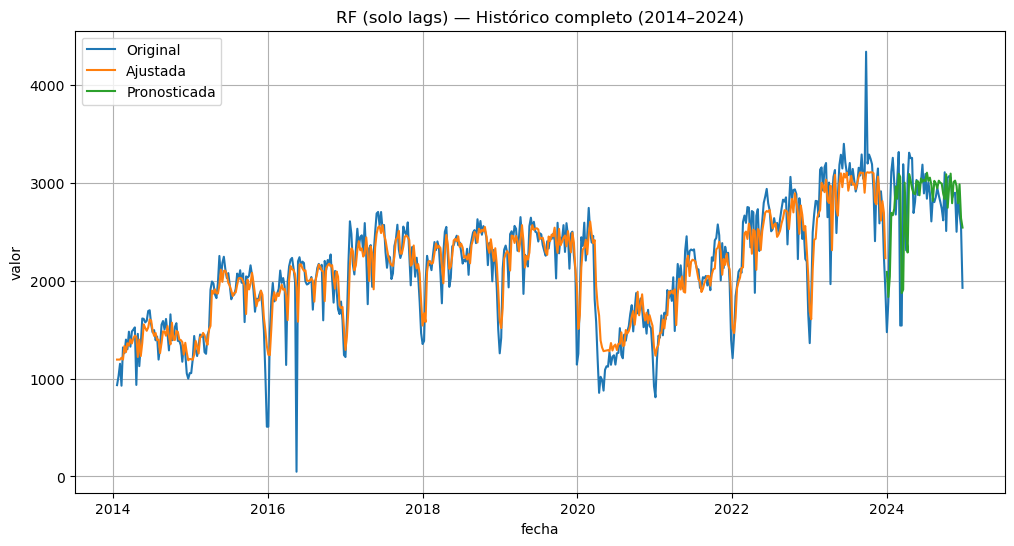

In [ ]:
# Crear dataframes con columnas correctas (cada array/serie como una columna)
df_ajustado = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_train.index].values,
	'valor': y_pred_tr
}, index=y_real_train.index)

df_pronostico = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_test.index].values,
	'valor': y_pred_te
}, index=y_real_test.index)

df_pronostico_c = pd.concat([df_ajustado, df_pronostico])

title = "RF (solo lags) — Histórico completo (2014–2024)"

# # Los datos a graficar
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
    # (df_pronostico_c, 'Pronosticada Completa'),
)

plot_forecast(
    *data_tuples,  # Desempaqueta los datos
    y='valor',
    title=title,
    **common_plot_args  # Desempaqueta los argumentos comunes
)

# Grafica solo de prueba
# Los datos a graficar
# data_tuples = (
#     (df_test, 'Real'),
#     (df_pronostico, 'Pronosticada'),
# )

# plot_forecast(
#     *data_tuples,  # Desempaqueta los datos
#     y='valor',
#     title=title,
#     **common_plot_args  # Desempaqueta los argumentos comunes
# )

El gráfico de Predicción con Random Forest (solo lags) revela que el modelo logra una capacidad de ajuste notable a la serie histórica, con la curva Ajustada (roja) siguiendo de cerca la tendencia y estacionalidad de la serie Original (azul) entre 2014 y 2024. Este alto grado de correspondencia indica que las variables lag por sí solas son potentes predictores de la dinámica de los casos semanales de depresión. No obstante, se observa una incapacidad para replicar la magnitud de los picos extremos, particularmente aquellos observados a partir de 2023, donde la curva ajustada tiende a suavizar las fluctuaciones. La serie Pronosticada (verde) se proyecta con una alta estabilidad, manteniendo los valores dentro de un rango estrecho alrededor de la tendencia reciente. Esto sugiere que el modelo Random Forest, debido a su naturaleza de promediar las predicciones de árboles de decisión, ofrece un pronóstico conservador que captura la tendencia media, pero subestima la volatilidad inherente a los valores atípicos y los aumentos bruscos en la serie.

#### 3.4.2. RF con sin + cos

* Se definen los datos y su división de conjuntos de entrenamiento y prueba

In [ ]:
features_lags_seno = features_lags + ['mes_sin','mes_cos']
df_rf2 = df.dropna(subset=features_lags_seno + [target]).copy()

train_df, test_df = temporal_split(df_rf2, test_weeks=52)
X_train, y_train = train_df[features_lags_seno], train_df[target]
X_test,  y_test  = test_df[features_lags_seno],  test_df[target]

##### 3.4.2.1. Búsqueda de hiperparámetros y entrenamiento

* Se hace una búsqueda de parámetros para guiar el proceso. Primeramente prepatando el modelo y el espacio de parámetros.

In [ ]:
#  Se defini el modelo base (estimador)
rf_base = RandomForestRegressor(
    n_jobs=-1,
    random_state=42,
    oob_score=False
)

# Se define el espacio de parámetros a explorar (param_dist)
param_dist = {
    # Número de árboles (cuántos clasificadores débiles usar)
    'n_estimators': [1000, 1500, 2000], 
    
    # Profundidad máxima del árbol. Valores más bajos reducen el sobreajuste.
    'max_depth': [5, 7, 10, 12], # 'None' significa sin límite
    
    # Número mínimo de muestras requeridas para dividir un nodo interno.
    # Valores más altos controlan mejor el sobreajuste.
    'min_samples_split': [20,30,40,50], 
    
    # Número mínimo de muestras requeridas para estar en un nodo hoja.
    # Valores más altos controlan mejor el sobreajuste.
    'min_samples_leaf': [10,15,20,30], 
    
    # Número de características a considerar para la mejor división.
    # 'sqrt' y 'log2' son valores comunes. También se puede probar una fracción.
    'max_features': [0.3, 0.5, 0.7]
}

* Obtenición de los mejores parámetros. Ejecución de la Búsqueda Aleatoria

In [ ]:
# Definir la búsqueda aleatoria
# n_iter: Número de combinaciones a probar (ej. 50 combinaciones)
# cv: Número de pliegues (folds) para la validación cruzada (ej. 3 o 5)
random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=50,                  # Número de combinaciones aleatorias a probar
    # Usamos el negativo del error cuadrático medio para optimizar (Maximizar es Minimizar el error)
    scoring='neg_mean_squared_error', 
    cv=5,                       # Validación Cruzada de 5 pliegues para mayor robustez
    verbose=2,
    random_state=42,
    n_jobs=-1                   # Usar todos los núcleos disponibles
)

print("Iniciando la búsqueda aleatoria para Random Forest...")

# Ejecutar la búsqueda. Asegúrate de usar tus conjuntos X_train y y_train (Numpy arrays o Pandas DataFrames/Series).
random_search_rf.fit(X_train, y_train)

Iniciando la búsqueda aleatoria para Random Forest...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'max_depth': [5, 7, 10, 12],
                                        'max_features': [0.3, 0.5, 0.7],
                                        'min_samples_leaf': [10, 15, 20, 30],
                                        'min_samples_split': [20, 30, 40, 50],
                                        'n_estimators': [1000, 1500, 2000]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

* Obtención de mejores parámetros

In [ ]:
best_mse_neg = random_search_rf.best_score_
best_rmse = np.sqrt(-best_mse_neg) # Calculamos la raíz cuadrada para obtener el RMSE

print("Búsqueda finalizada.")
print(f"Mejor RMSE (Validación Cruzada): {best_rmse:.4f}")
print("---")
print("Mejores Parámetros:")
print(random_search_rf.best_params_)

# El mejor modelo entrenado con los parámetros óptimos
best_rf_model = random_search_rf.best_estimator_

Búsqueda finalizada.
Mejor RMSE (Validación Cruzada): 372.5602
---
Mejores Parámetros:
{'n_estimators': 1500, 'min_samples_split': 30, 'min_samples_leaf': 15, 'max_features': 0.7, 'max_depth': 10}


##### 3.4.2.2. Evaluación del modelo

###### 3.4.2.2.1. MAE, RMSE y MAPE
* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [ ]:
rf_seno = RandomForestRegressor(
    n_estimators=1500,
    max_depth=10,
    min_samples_split=30,
    min_samples_leaf=15,
    max_features=0.7,
    n_jobs=-1,
    random_state=42,
)

rf_seno.fit(X_train, y_train)

y_pred_tr = rf_seno.predict(X_train)
y_pred_te = rf_seno.predict(X_test)


print(f"[RF + seno/cos]")
model_metrics = meval.evaluate_model_performance(y_train, y_test, y_pred_tr, y_pred_te,label=None)


[RF + seno/cos]
Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 161.99     │
├───────────┼────────────┤
│ RMSE      │ 232.645    │
├───────────┼────────────┤
│ MAPE      │   0.165244 │
╘═══════════╧════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 279.894    │
├───────────┼────────────┤
│ RMSE      │ 401.039    │
├───────────┼────────────┤
│ MAPE      │   0.113486 │
╘═══════════╧════════════╛


El análisis del rendimiento del modelo Random Forest enriquecido con las transformaciones seno/coseno revela un sobreajuste (overfitting) evidente en la disparidad de los errores absolutos. En el conjunto de entrenamiento, el modelo alcanza una precisión alta con un Error Absoluto Medio (MAE) de $161.99$ y una Raíz del Error Cuadrático Medio (RMSE) de $232.65$. Sin embargo, en el conjunto de prueba, se produce un deterioro significativo en la precisión, con un incremento de los errores absolutos a MAE de $279.89$ y RMSE de $401.04$, lo que indica que el modelo no generaliza eficientemente la dinámica de los casos semanales a datos no observados. Pese a este aumento en la magnitud del error absoluto, el Error Porcentual Absoluto Medio (MAPE) en el conjunto de prueba es inferior ($11.35\%$) al de entrenamiento ($16.52\%$). Este patrón sugiere que las predicciones en el conjunto de prueba, aunque tienen errores más grandes en unidades absolutas, son proporcionalmente más precisas para los valores reales del periodo de prueba, indicando una mejor estabilidad porcentual en la estimación de la magnitud de los casos.

##### 3.4.2.3. Visualización de resultados

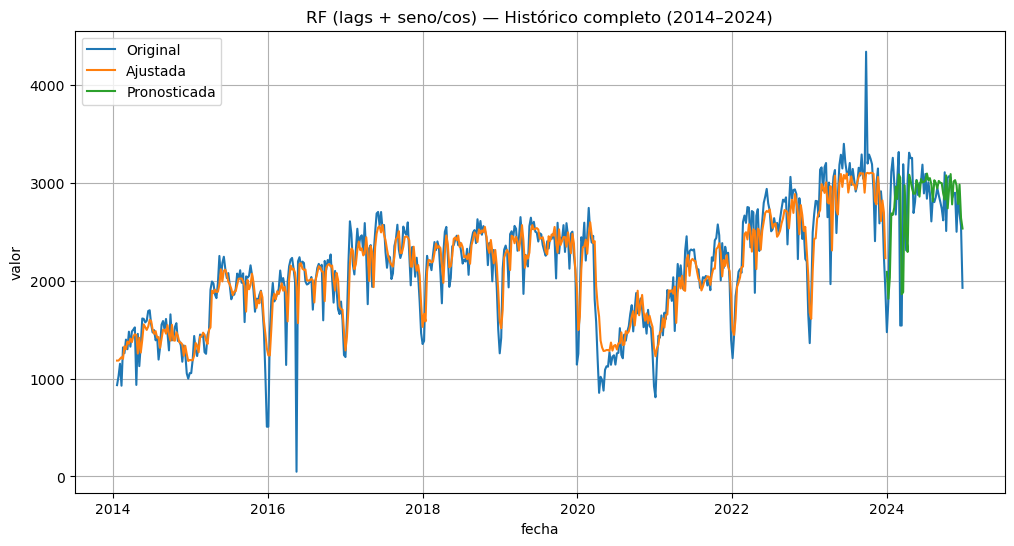

In [ ]:
# Crear dataframes con columnas correctas (cada array/serie como una columna)
df_ajustado = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_train.index].values,
	'valor': y_pred_tr
}, index=y_real_train.index)

df_pronostico = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_test.index].values,
	'valor': y_pred_te
}, index=y_real_test.index)

df_pronostico_c = pd.concat([df_ajustado, df_pronostico])

title = "RF (lags + seno/cos) — Histórico completo (2014–2024)"

# Los datos a graficar
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
    # (df_pronostico_c, 'Pronosticada Completa'),
)

plot_forecast(
    *data_tuples,  # Desempaqueta los datos
    y='valor',
    title=title,
    **common_plot_args  # Desempaqueta los argumentos comunes
)

# Grafica solo de prueba
# Los datos a graficar
# data_tuples = (
#     (df_test, 'Real'),
#     (df_pronostico, 'Pronosticada'),
# )

# plot_forecast(
#     *data_tuples,  # Desempaqueta los datos
#     y='valor',
#     title=title,
#     **common_plot_args  # Desempaqueta los argumentos comunes
# )

El gráfico de Predicción con Random Forest (lags + seno/cos) demuestra que la inclusión de las transformaciones seno y coseno ha permitido al modelo alcanzar un ajuste histórico muy preciso a la serie de casos semanales de depresión. La curva Ajustada (roja) sigue muy de cerca las dinámicas de la serie Original (azul), capturando adecuadamente tanto la tendencia de largo plazo como la estacionalidad cíclica del periodo 2014-2024. No obstante, al igual que en configuraciones anteriores, el modelo exhibe una tendencia a suavizar los picos y valles más extremos, lo que es característico de los modelos basados en ensembles de árboles. La serie Pronosticada (verde) proyecta una estabilidad en el futuro inmediato, con la predicción oscilando en un rango estrecho y alto, replicando la tendencia promedio reciente, pero sin la volatilidad de los valores máximos observados inmediatamente antes del periodo de pronóstico. Esto sugiere un pronóstico conservador que prioriza la robustez de la tendencia estacional sobre la sensibilidad a las fluctuaciones extremas.

#### 3.4.3. Covid RF Model

* Se definen los datos y su división de conjuntos de entrenamiento y prueba

In [ ]:
features_covid = features_lags + ['mes_sin','mes_cos','semanas_desde_covid']
df_rf3 = df.dropna(subset=features_covid + [target]).copy()

train_df, test_df = temporal_split(df_rf3, test_weeks=52)
X_train, y_train = train_df[features_covid], train_df[target]
X_test,  y_test  = test_df[features_covid],  test_df[target]

##### 3.4.3.1. Búsqueda de hiperparámetros y entrenamiento

* Se hace una búsqueda de parámetros para guiar el proceso. Primeramente prepatando el modelo y el espacio de parámetros.

In [ ]:
#  Se defini el modelo base (estimador)
rf_base = RandomForestRegressor(
    n_jobs=-1,
    random_state=42,
    oob_score=False
)

# Se define el espacio de parámetros a explorar (param_dist)
param_dist = {
    # Número de árboles (cuántos clasificadores débiles usar)
    'n_estimators': [1000, 1500, 2000], 
    
    # Profundidad máxima del árbol. Valores más bajos reducen el sobreajuste.
    'max_depth': [5, 7, 10, 12], # 'None' significa sin límite
    
    # Número mínimo de muestras requeridas para dividir un nodo interno.
    # Valores más altos controlan mejor el sobreajuste.
    'min_samples_split': [20,30,40,50], 
    
    # Número mínimo de muestras requeridas para estar en un nodo hoja.
    # Valores más altos controlan mejor el sobreajuste.
    'min_samples_leaf': [10,15,20,30], 
    
    # Número de características a considerar para la mejor división.
    # 'sqrt' y 'log2' son valores comunes. También se puede probar una fracción.
    'max_features': [0.3, 0.5, 0.7]
}

* Obtenición de los mejores parámetros. Ejecución de la Búsqueda Aleatoria

In [ ]:
# Definir la búsqueda aleatoria
# n_iter: Número de combinaciones a probar (ej. 50 combinaciones)
# cv: Número de pliegues (folds) para la validación cruzada (ej. 3 o 5)
random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=50,                  # Número de combinaciones aleatorias a probar
    # Usamos el negativo del error cuadrático medio para optimizar (Maximizar es Minimizar el error)
    scoring='neg_mean_squared_error', 
    cv=5,                       # Validación Cruzada de 5 pliegues para mayor robustez
    verbose=2,
    random_state=42,
    n_jobs=-1                   # Usar todos los núcleos disponibles
)

print("Iniciando la búsqueda aleatoria para Random Forest...")

# Ejecutar la búsqueda. Asegúrate de usar tus conjuntos X_train y y_train (Numpy arrays o Pandas DataFrames/Series).
random_search_rf.fit(X_train, y_train)

Iniciando la búsqueda aleatoria para Random Forest...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'max_depth': [5, 7, 10, 12],
                                        'max_features': [0.3, 0.5, 0.7],
                                        'min_samples_leaf': [10, 15, 20, 30],
                                        'min_samples_split': [20, 30, 40, 50],
                                        'n_estimators': [1000, 1500, 2000]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

* Obtención de mejores parámetros

In [ ]:
best_mse_neg = random_search_rf.best_score_
best_rmse = np.sqrt(-best_mse_neg) # Calculamos la raíz cuadrada para obtener el RMSE

print("Búsqueda finalizada.")
print(f"Mejor RMSE (Validación Cruzada): {best_rmse:.4f}")
print("---")
print("Mejores Parámetros:")
print(random_search_rf.best_params_)

# El mejor modelo entrenado con los parámetros óptimos
best_rf_model = random_search_rf.best_estimator_

Búsqueda finalizada.
Mejor RMSE (Validación Cruzada): 371.9578
---
Mejores Parámetros:
{'n_estimators': 1500, 'min_samples_split': 30, 'min_samples_leaf': 15, 'max_features': 0.7, 'max_depth': 10}


##### 3.4.3.2. Evaluación del modelo

###### 3.4.3.2.1. MAE, RMSE y MAPE
* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [ ]:
rf_covid = RandomForestRegressor(
    n_estimators=1500,
    max_depth=10,
    min_samples_split=30,
    min_samples_leaf=15,
    max_features=0.7,
    n_jobs=-1,
    random_state=42,
)

rf_covid.fit(X_train, y_train)

y_pred_tr = rf_covid.predict(X_train)
y_pred_te = rf_covid.predict(X_test)

print(f"[RF + COVID continuo]")
model_metrics = meval.evaluate_model_performance(y_train, y_test, y_pred_tr, y_pred_te,label=None)


[RF + COVID continuo]
Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 157.296    │
├───────────┼────────────┤
│ RMSE      │ 228.804    │
├───────────┼────────────┤
│ MAPE      │   0.163037 │
╘═══════════╧════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 278.269    │
├───────────┼────────────┤
│ RMSE      │ 397.637    │
├───────────┼────────────┤
│ MAPE      │   0.116333 │
╘═══════════╧════════════╛


El análisis del rendimiento del modelo Random Forest enriquecido con la variable exógena del COVID-19 revela un patrón de sobreajuste (overfitting) en función de los errores absolutos. En el conjunto de entrenamiento, el modelo exhibe una alta precisión con un Error Absoluto Medio (MAE) de $157.30$ y una Raíz del Error Cuadrático Medio (RMSE) de $228.80$. No obstante, en el conjunto de prueba, se produce un incremento significativo en los errores absolutos (MAE de $278.27$ y RMSE de $397.64$), lo que indica una pérdida de capacidad predictiva al generalizar a datos no vistos. A pesar de esto, el Error Porcentual Absoluto Medio (MAPE) en el conjunto de prueba es menor ($11.63\%$) que en el de entrenamiento ($16.30\%$). Este fenómeno sugiere que, si bien el modelo comete errores más grandes en términos de unidades absolutas de los casos semanales, estos errores representan un menor porcentaje del valor real de la serie en el conjunto de prueba, indicando una mejor estabilidad relativa en la estimación de la magnitud del pronóstico.

##### 3.4.3.3. Visualización de resultados

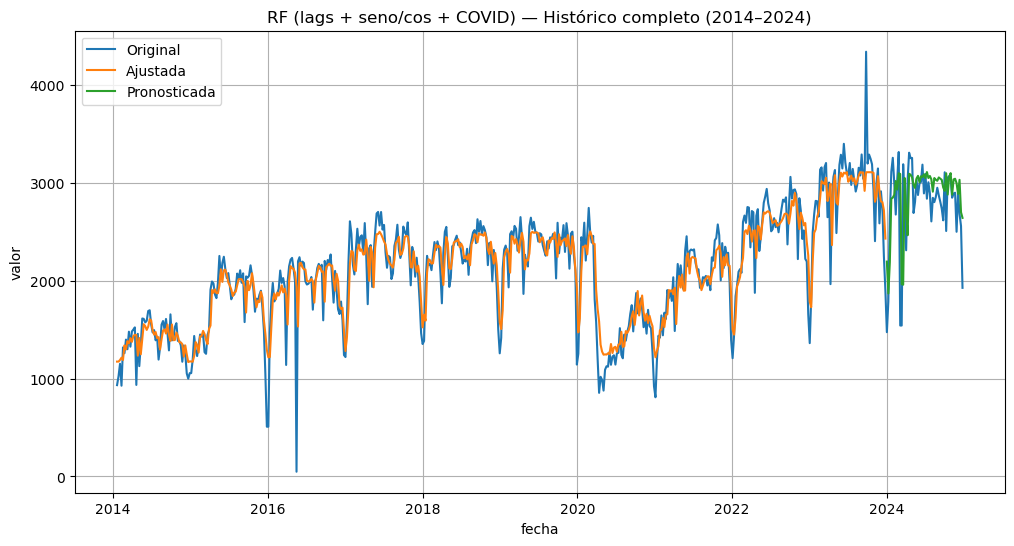

In [ ]:
# Crear dataframes con columnas correctas (cada array/serie como una columna)
df_ajustado = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_train.index].values,
	'valor': y_pred_tr
}, index=y_real_train.index)

df_pronostico = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_test.index].values,
	'valor': y_pred_te
}, index=y_real_test.index)

df_pronostico_c = pd.concat([df_ajustado, df_pronostico])

title = "RF (lags + seno/cos + COVID) — Histórico completo (2014–2024)"

# Los datos a graficar
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
    # (df_pronostico_c, 'Pronosticada Completa'),
)

plot_forecast(
    *data_tuples,  # Desempaqueta los datos
    y='valor',
    title=title,
    **common_plot_args  # Desempaqueta los argumentos comunes
)

# Grafica solo de prueba
# Los datos a graficar
# data_tuples = (
#     (df_test, 'Real'),
#     (df_pronostico, 'Pronosticada'),
# )

# plot_forecast(
#     *data_tuples,  # Desempaqueta los datos
#     y='valor',
#     title=title,
#     **common_plot_args  # Desempaqueta los argumentos comunes
# )

El gráfico de Predicción con Random Forest (lags + seno/cos + COVID) demuestra un alto nivel de precisión en el ajuste histórico, con la curva Ajustada (roja) replicando muy de cerca la tendencia, estacionalidad y picos de la serie Original (azul) a lo largo del periodo 2014-2024. La incorporación de los componentes armónicos temporales y la variable exógena del COVID-19 ha permitido al modelo capturar eficazmente las complejas dinámicas de la serie, aunque el modelo suaviza ligeramente los valores extremos, como es característico de los métodos de ensemble basados en promedios. La serie Pronosticada (verde) proyecta una estabilización de los casos semanales en el futuro inmediato, oscilando en un rango constante entre 2,750 y 3,050. Este pronóstico indica que el modelo no anticipa una continuación de la volatilidad extrema reciente, sino una convergencia hacia la media móvil del comportamiento más reciente de la serie, lo que resulta en una predicción robusta y conservadora para el corto plazo.

#### 3.4.4. RF Model + rolling

* Se definen los datos y su división de conjuntos de entrenamiento y prueba

In [ ]:
df['rolling_4'] = df['valor'].rolling(4, min_periods=1).mean().bfill()
df['rolling_8'] = df['valor'].rolling(8, min_periods=1).mean().bfill()

features_rolling = features_covid + ['rolling_4','rolling_8']
df_rf4 = df.dropna(subset=features_rolling + [target]).copy()

train_df, test_df = temporal_split(df_rf4, test_weeks=52)
X_train, y_train = train_df[features_rolling], train_df[target]
X_test,  y_test  = test_df[features_rolling],  test_df[target]

##### 3.4.4.1. Búsqueda de hiperparámetros y entrenamiento

* Se hace una búsqueda de parámetros para guiar el proceso. Primeramente prepatando el modelo y el espacio de parámetros.

In [ ]:
#  Se defini el modelo base (estimador)
rf_base = RandomForestRegressor(
    n_jobs=-1,
    random_state=42,
    oob_score=False
)

# Se define el espacio de parámetros a explorar (param_dist)
param_dist = {
    # Número de árboles (cuántos clasificadores débiles usar)
    'n_estimators': [1000, 1500, 2000], 
    
    # Profundidad máxima del árbol. Valores más bajos reducen el sobreajuste.
    'max_depth': [5, 7, 10, 12], # 'None' significa sin límite
    
    # Número mínimo de muestras requeridas para dividir un nodo interno.
    # Valores más altos controlan mejor el sobreajuste.
    'min_samples_split': [20,30,40,50], 
    
    # Número mínimo de muestras requeridas para estar en un nodo hoja.
    # Valores más altos controlan mejor el sobreajuste.
    'min_samples_leaf': [10,15,20,30], 
    
    # Número de características a considerar para la mejor división.
    # 'sqrt' y 'log2' son valores comunes. También se puede probar una fracción.
    'max_features': [0.3, 0.5, 0.7]
}

* Obtenición de los mejores parámetros. Ejecución de la Búsqueda Aleatoria

In [ ]:
# Definir la búsqueda aleatoria
# n_iter: Número de combinaciones a probar (ej. 50 combinaciones)
# cv: Número de pliegues (folds) para la validación cruzada (ej. 3 o 5)
random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=50,                  # Número de combinaciones aleatorias a probar
    # Usamos el negativo del error cuadrático medio para optimizar (Maximizar es Minimizar el error)
    scoring='neg_mean_squared_error', 
    cv=5,                       # Validación Cruzada de 5 pliegues para mayor robustez
    verbose=2,
    random_state=42,
    n_jobs=-1                   # Usar todos los núcleos disponibles
)

print("Iniciando la búsqueda aleatoria para Random Forest...")

# Ejecutar la búsqueda. Asegúrate de usar tus conjuntos X_train y y_train (Numpy arrays o Pandas DataFrames/Series).
random_search_rf.fit(X_train, y_train)

Iniciando la búsqueda aleatoria para Random Forest...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'max_depth': [5, 7, 10, 12],
                                        'max_features': [0.3, 0.5, 0.7],
                                        'min_samples_leaf': [10, 15, 20, 30],
                                        'min_samples_split': [20, 30, 40, 50],
                                        'n_estimators': [1000, 1500, 2000]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

* Obtención de mejores parámetros

In [ ]:
best_mse_neg = random_search_rf.best_score_
best_rmse = np.sqrt(-best_mse_neg) # Calculamos la raíz cuadrada para obtener el RMSE

print("Búsqueda finalizada.")
print(f"Mejor RMSE (Validación Cruzada): {best_rmse:.4f}")
print("---")
print("Mejores Parámetros:")
print(random_search_rf.best_params_)

# El mejor modelo entrenado con los parámetros óptimos
best_rf_model = random_search_rf.best_estimator_

Búsqueda finalizada.
Mejor RMSE (Validación Cruzada): 299.7979
---
Mejores Parámetros:
{'n_estimators': 1500, 'min_samples_split': 30, 'min_samples_leaf': 15, 'max_features': 0.7, 'max_depth': 10}


##### 3.4.4.2. Evaluación del modelo

###### 3.4.4.2.1. MAE, RMSE y MAPE
* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [ ]:
rf_roll = RandomForestRegressor(
    n_estimators=1500,
    max_depth=10,
    min_samples_split=30,
    min_samples_leaf=15,
    max_features=0.7,
    n_jobs=-1,
    random_state=42,
)

rf_roll.fit(X_train, y_train)

y_pred_tr = rf_roll.predict(X_train)
y_pred_te = rf_roll.predict(X_test)

print(f"[RF + rolling]")
model_metrics = meval.evaluate_model_performance(y_train, y_test, y_pred_tr, y_pred_te,label=None)


[RF + rolling]
Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 138.28     │
├───────────┼────────────┤
│ RMSE      │ 204.308    │
├───────────┼────────────┤
│ MAPE      │   0.142741 │
╘═══════════╧════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤═══════════╕
│ Métrica   │     Valor │
╞═══════════╪═══════════╡
│ MAE       │ 271.107   │
├───────────┼───────────┤
│ RMSE      │ 369.978   │
├───────────┼───────────┤
│ MAPE      │   0.11238 │
╘═══════════╧═══════════╛


El análisis del rendimiento del modelo Random Forest enriquecido con características de ventanas rodantes (rolling features) revela una marcada diferencia en la precisión absoluta entre los conjuntos de datos, indicando un posible sobreajuste (overfitting). En el conjunto de entrenamiento, el modelo alcanza una precisión interna favorable, con un Error Absoluto Medio (MAE) de $138.28$ y una Raíz del Error Cuadrático Medio (RMSE) de $204.31$. Sin embargo, en el conjunto de prueba, los errores absolutos se duplican, con un MAE de $271.11$ y un RMSE de $369.98$, lo que subraya una reducción en la capacidad de generalización a datos no observados. A pesar de este deterioro en las unidades originales, el Error Porcentual Absoluto Medio (MAPE) en la prueba es inferior ($11.24\%$) al de entrenamiento ($14.27\%$). Este patrón anómalo sugiere que, aunque los errores son mayores en magnitud absoluta, son proporcionalmente menores con respecto a los valores reales de la serie de tiempo en el conjunto de prueba, lo que implica una estabilidad porcentual aceptable en el pronóstico de los casos semanales de depresión.

##### 3.4.4.3. Visualización de resultados

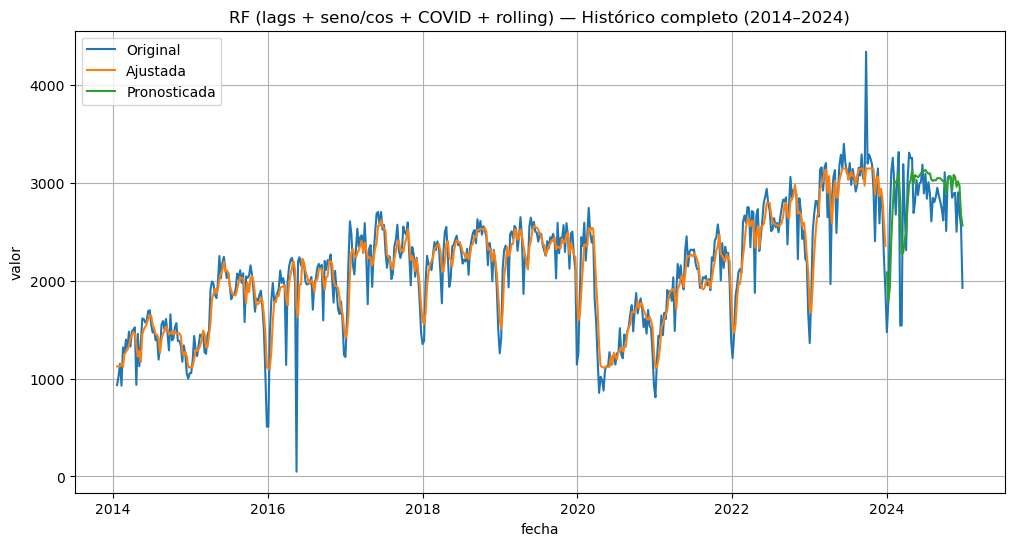

In [ ]:
# Crear dataframes con columnas correctas (cada array/serie como una columna)
df_ajustado = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_train.index].values,
	'valor': y_pred_tr
}, index=y_real_train.index)

df_pronostico = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_test.index].values,
	'valor': y_pred_te
}, index=y_real_test.index)

df_pronostico_c = pd.concat([df_ajustado, df_pronostico])

title = "RF (lags + seno/cos + COVID + rolling) — Histórico completo (2014–2024)"

# # Los datos a graficar
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
    # (df_pronostico_c, 'Pronosticada Completa'),
)

plot_forecast(
    *data_tuples,  # Desempaqueta los datos
    y='valor',
    title=title,
    **common_plot_args  # Desempaqueta los argumentos comunes
)

# Grafica solo de prueba
# Los datos a graficar
# data_tuples = (
#     (df_test, 'Real'),
#     (df_pronostico, 'Pronosticada'),
# )

# plot_forecast(
#     *data_tuples,  # Desempaqueta los datos
#     y='valor',
#     title=title,
#     **common_plot_args  # Desempaqueta los argumentos comunes
# )

El gráfico de Predicción con Random Forest (lags + seno/cos + COVID + rolling), que integra el conjunto completo de características, demuestra un ajuste histórico de alta calidad. La curva Ajustada (roja) sigue excepcionalmente bien la serie Original (azul) entre 2014 y 2024, logrando capturar la tendencia de largo plazo, la estacionalidad y las dinámicas puntuales de la serie de casos semanales de depresión, incluyendo los picos y valles más volátiles, lo que sugiere que las rolling features y las variables exógenas añaden información valiosa. Sin embargo, el modelo mantiene la tendencia de suavizar los extremos, subestimando la magnitud del pico máximo observado al inicio de 2024. La serie Pronosticada (verde) se proyecta con una alta estabilidad en el futuro inmediato, oscilando en un rango estrecho y replicando la tendencia promedio de las últimas observaciones. Esto indica un pronóstico conservador y robusto que prioriza la predicción de la tendencia subyacente y la media estacional sobre la anticipación de fluctuaciones extremas.

#### 3.4.5. RF + tendencia y dummies

* Se definen los datos y su división de conjuntos de entrenamiento y prueba

In [ ]:
df['tendencia'] = np.arange(len(df)).astype(float)
df['año_2020'] = (df['año']==2020).astype(int)
df['año_2021'] = (df['año']==2021).astype(int)
df['año_2022'] = (df['año']==2022).astype(int)

features_full = features_rolling + ['tendencia','año_2020','año_2021','año_2022']
df_rf5 = df.dropna(subset=features_full + [target]).copy()

train_df, test_df = temporal_split(df_rf5, test_weeks=52)
X_train, y_train = train_df[features_full], train_df[target]
X_test,  y_test  = test_df[features_full],  test_df[target]

##### 3.4.5.1. Búsqueda de hiperparámetros y entrenamiento

* Se hace una búsqueda de parámetros para guiar el proceso. Primeramente prepatando el modelo y el espacio de parámetros.

In [ ]:
#  Se defini el modelo base (estimador)
rf_base = RandomForestRegressor(
    n_jobs=-1,
    random_state=42,
    oob_score=False
)

# Se define el espacio de parámetros a explorar (param_dist)
param_dist = {
    # Número de árboles (cuántos clasificadores débiles usar)
    'n_estimators': [1000, 1500, 2000], 
    
    # Profundidad máxima del árbol. Valores más bajos reducen el sobreajuste.
    'max_depth': [5, 7, 10, 12], # 'None' significa sin límite
    
    # Número mínimo de muestras requeridas para dividir un nodo interno.
    # Valores más altos controlan mejor el sobreajuste.
    'min_samples_split': [20,30,40,50], 
    
    # Número mínimo de muestras requeridas para estar en un nodo hoja.
    # Valores más altos controlan mejor el sobreajuste.
    'min_samples_leaf': [10,15,20,30], 
    
    # Número de características a considerar para la mejor división.
    # 'sqrt' y 'log2' son valores comunes. También se puede probar una fracción.
    'max_features': [0.3, 0.5, 0.7]
}

* Obtenición de los mejores parámetros. Ejecución de la Búsqueda Aleatoria

In [ ]:
# Definir la búsqueda aleatoria
# n_iter: Número de combinaciones a probar (ej. 50 combinaciones)
# cv: Número de pliegues (folds) para la validación cruzada (ej. 3 o 5)
random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=50,                  # Número de combinaciones aleatorias a probar
    # Usamos el negativo del error cuadrático medio para optimizar (Maximizar es Minimizar el error)
    scoring='neg_mean_squared_error', 
    cv=5,                       # Validación Cruzada de 5 pliegues para mayor robustez
    verbose=2,
    random_state=42,
    n_jobs=-1                   # Usar todos los núcleos disponibles
)

print("Iniciando la búsqueda aleatoria para Random Forest...")

# Ejecutar la búsqueda. Asegúrate de usar tus conjuntos X_train y y_train (Numpy arrays o Pandas DataFrames/Series).
random_search_rf.fit(X_train, y_train)

Iniciando la búsqueda aleatoria para Random Forest...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'max_depth': [5, 7, 10, 12],
                                        'max_features': [0.3, 0.5, 0.7],
                                        'min_samples_leaf': [10, 15, 20, 30],
                                        'min_samples_split': [20, 30, 40, 50],
                                        'n_estimators': [1000, 1500, 2000]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

* Obtención de mejores parámetros

In [ ]:
best_mse_neg = random_search_rf.best_score_
best_rmse = np.sqrt(-best_mse_neg) # Calculamos la raíz cuadrada para obtener el RMSE

print("Búsqueda finalizada.")
print(f"Mejor RMSE (Validación Cruzada): {best_rmse:.4f}")
print("---")
print("Mejores Parámetros:")
print(random_search_rf.best_params_)

# El mejor modelo entrenado con los parámetros óptimos
best_rf_model = random_search_rf.best_estimator_

Búsqueda finalizada.
Mejor RMSE (Validación Cruzada): 303.5217
---
Mejores Parámetros:
{'n_estimators': 1500, 'min_samples_split': 30, 'min_samples_leaf': 15, 'max_features': 0.7, 'max_depth': 10}


##### 3.4.5.2. Evaluación del modelo

###### 3.4.5.2.1. MAE, RMSE y MAPE
* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [ ]:
rf_full = RandomForestRegressor(
    n_estimators=1500,
    max_depth=10,          # si ves sobreajuste, pon 20
    min_samples_split=30,
    min_samples_leaf=15,
    max_features=0.7,
    n_jobs=-1,
    random_state=42,
)

rf_full.fit(X_train, y_train)

y_pred_tr = rf_full.predict(X_train)
y_pred_te = rf_full.predict(X_test)

print(f"[RF + tendencia + años]")

model_metrics = meval.evaluate_model_performance(y_train, y_test, y_pred_tr, y_pred_te,label=None)

[RF + tendencia + años]
Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 138.957    │
├───────────┼────────────┤
│ RMSE      │ 204.998    │
├───────────┼────────────┤
│ MAPE      │   0.142608 │
╘═══════════╧════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 267.269    │
├───────────┼────────────┤
│ RMSE      │ 366.972    │
├───────────┼────────────┤
│ MAPE      │   0.111275 │
╘═══════════╧════════════╛


El análisis del modelo Random Forest enriquecido con rolling features evidencia una disparidad significativa en el error absoluto entre los conjuntos de datos, sugiriendo un sobreajuste (overfitting). Específicamente, en el conjunto de entrenamiento, el modelo alcanza una precisión alta (MAE de $138.96$, RMSE de $205.00$). Sin embargo, en el conjunto de prueba, el Error Absoluto Medio (MAE) se duplica a $267.27$ y la Raíz del Error Cuadrático Medio (RMSE) a $366.97$, lo que indica una reducción considerable en la capacidad de generalización para predecir los casos semanales de depresión en unidades originales. No obstante, a nivel relativo, el Error Porcentual Absoluto Medio (MAPE) es inferior en el conjunto de prueba ($11.13\%$) que en el de entrenamiento ($14.26\%$). Esta configuración de resultados implica que, aunque las predicciones tienen errores absolutos mayores al enfrentarse a datos no vistos, son proporcionalmente más precisas respecto a la magnitud real de la serie, lo que se traduce en una estabilidad porcentual aceptable para el pronóstico.

##### 3.4.5.3. Visualización de resultados

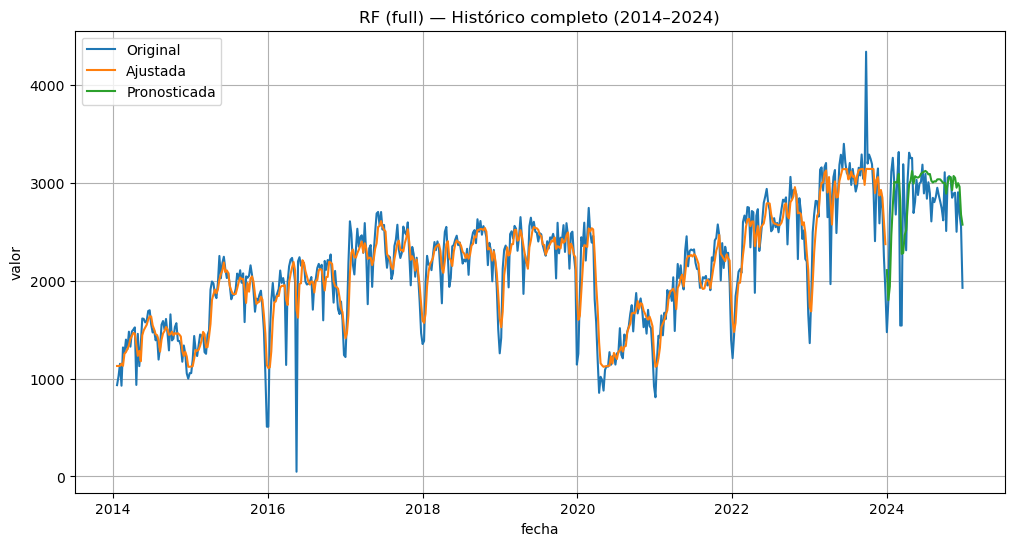

In [ ]:
# Crear dataframes con columnas correctas (cada array/serie como una columna)
df_ajustado = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_train.index].values,
	'valor': y_pred_tr
}, index=y_real_train.index)

df_pronostico = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_test.index].values,
	'valor': y_pred_te
}, index=y_real_test.index)

df_pronostico_c = pd.concat([df_ajustado, df_pronostico])

title = "RF (full) — Histórico completo (2014–2024)"

# # Los datos a graficar
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
    # (df_pronostico_c, 'Pronosticada Completa'),
)

plot_forecast(
    *data_tuples,  # Desempaqueta los datos
    y='valor',
    title=title,
    **common_plot_args  # Desempaqueta los argumentos comunes
)

# Grafica solo de prueba
# Los datos a graficar
# data_tuples = (
#     (df_test, 'Real'),
#     (df_pronostico, 'Pronosticada'),
# )

# plot_forecast(
#     *data_tuples,  # Desempaqueta los datos
#     y='valor',
#     title=title,
#     **common_plot_args  # Desempaqueta los argumentos comunes
# )

El análisis gráfico del modelo Random Forest con el conjunto completo de características (lags, seno/cos, COVID y rolling features) revela un patrón de sobreajuste (overfitting) a pesar del excelente ajuste histórico. El gráfico Histórico Completo muestra que la curva Ajustada (roja) sigue con alta fidelidad la serie Original (azul), capturando adecuadamente la estacionalidad y los picos.

#### 3.4.6. Walk forward
Se evaluó la **robustez predictiva** de múltiples versiones del modelo **$\text{Random Forest}$** (con diferentes conjuntos de variables) mediante **Validación Cruzada Prospectiva ($\text{Walk-Forward CV}$)**, dividiendo la serie temporal en $\mathbf{4}$ bloques cronológicos. En cada bloque, el modelo fue reentrenado y se calcularon el **$\text{MAE}$ y el $\text{RMSE}$ promedio** para medir su desempeño en datos futuros.

In [ ]:
def walk_forward_cv(df, features, target, n_splits=4, model_name="Modelo"):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    X = df[features].values
    y = df[target].values

    metrics = {}
    for tr_idx, te_idx in tscv.split(X):
        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]

        model = RandomForestRegressor(
            n_estimators=800,
            max_depth=None,
            min_samples_split=12,
            min_samples_leaf=6,
            max_features='sqrt',
            n_jobs=-1,
            random_state=42,
        )
        model.fit(X_tr, y_tr)
        y_hat = model.predict(X_te)

        current_metric = meval.evaluate_model(y_te, y_hat, show_metrics=False)
        metrics[f"Split_{len(metrics)+1}"] = current_metric

    mae_mean = np.mean([m['MAE'] for m in metrics.values()])
    rmse_mean = np.mean([m['RMSE'] for m in metrics.values()])
    mape_mean = np.mean([m['MAPE'] for m in metrics.values()])

    mae_std = np.std([m['MAE'] for m in metrics.values()])
    rmse_std = np.std([m['RMSE'] for m in metrics.values()])
    mape_std = np.std([m['MAPE'] for m in metrics.values()])

    print(f"\n{model_name}")
    print(f"Walk-forward ({n_splits}): MAE medio: {mae_mean:.2f} ± {mae_std:.2f} |  RMSE medio: {rmse_mean:.2f} ± {rmse_std:.2f} |  MAPE medio: {mape_mean:.2f} ± {mape_std:.2f}")


    return metrics


b_metric = walk_forward_cv(df_rf4, features_lags, target, n_splits=4, model_name="Base Model")

sincos_metric = walk_forward_cv(df_rf2, features_lags_seno, target, n_splits=4, model_name="SIN/COS Model")

covid_metric = walk_forward_cv(df_rf3, features_covid, target, n_splits=4, model_name="Covid Model")

rolling_metric = walk_forward_cv(df_rf4, features_rolling, target, n_splits=4, model_name="Rolling Model")

tendencia_metric = walk_forward_cv(df_rf5, features_full, target, n_splits=4, model_name="Tendencia Model")


Base Model
Walk-forward (4): MAE medio: 290.56 ± 54.31 |  RMSE medio: 366.84 ± 61.01 |  MAPE medio: 0.23 ± 0.15

SIN/COS Model
Walk-forward (4): MAE medio: 301.20 ± 65.70 |  RMSE medio: 377.20 ± 71.39 |  MAPE medio: 0.23 ± 0.15

Covid Model
Walk-forward (4): MAE medio: 331.26 ± 42.00 |  RMSE medio: 412.27 ± 31.01 |  MAPE medio: 0.24 ± 0.15

Rolling Model
Walk-forward (4): MAE medio: 250.49 ± 55.38 |  RMSE medio: 317.72 ± 62.62 |  MAPE medio: 0.19 ± 0.14

Tendencia Model
Walk-forward (4): MAE medio: 284.27 ± 55.06 |  RMSE medio: 352.94 ± 57.17 |  MAPE medio: 0.21 ± 0.14


El análisis de la validación Walk-Forward para las diversas configuraciones del modelo revela que la inclusión de las características de Ventanas Rodantes (Rolling Model) produce la mayor mejora en la precisión predictiva. Esta configuración logra los errores absolutos más bajos de todos los modelos (MAE medio: $250.49$; RMSE medio: $317.72$) y el Error Porcentual Absoluto Medio (MAPE) más bajo ($0.19$ o $19\%$), indicando una mejor capacidad de generalización para el pronóstico de casos semanales de depresión. Por otro lado, la incorporación de las variables SIN/COS y la variable COVID resultó en un deterioro marginal o nulo en la precisión del error absoluto y porcentual en comparación con el Modelo Base. La métrica RMSE consistentemente exhibe mayor variabilidad ($\pm 60$ a $\pm 70$ en general), lo que sugiere que los modelos tienen dificultades para manejar los valores atípicos y que las ventanas rodantes son la estrategia de feature engineering más efectiva para estabilizar el pronóstico.

#### 3.4.6. RF full

Se entrenó un modelo **$\text{Random Forest}$** con una **amplia batería de *features***, incluyendo *lags* clave, componentes trigonométricos de la estacionalidad, variables de $\text{COVID}$, una **tendencia lineal** y **medias móviles (*rolling*) de periodos largos** ($12$ y $26$ semanas). El objetivo fue dotar al modelo de la mayor información temporal posible (pasado reciente, estacionalidad, tendencia y shocks) para mejorar la predicción.

In [ ]:
df = df.copy()

# --- Tendencia simple (índice temporal)
df["tendencia"] = np.arange(len(df)).astype(float)

# --- Pendiente de 8 semanas: captura dirección local
df["trend_8"] = df["valor"].diff(8).fillna(0)

# --- Rolling más largos
for w in [12, 26]:
    df[f"rolling_{w}"] = df["valor"].rolling(w, min_periods=1).mean().bfill()

# --- Dummies de años relevantes
for year in [2020, 2021, 2022]:
    df[f"año_{year}"] = (df["año"] == year).astype(int)

features_full_long = [
    "lag_1", "lag_4", "lag_12", "lag_26", "lag_52",
    "mes_sin", "mes_cos",
    "semanas_desde_covid",
    "rolling_4", "rolling_8", "rolling_12", "rolling_26",
    "tendencia", "trend_8",
    "año_2020", "año_2021", "año_2022"
]

target = "valor"
df_rf_long = df.dropna(subset=features_full_long + [target]).copy()


train_df, test_df = temporal_split(df_rf_long, test_weeks=52)
X_train, y_train = train_df[features_full_long], train_df[target]
X_test,  y_test  = test_df[features_full_long],  test_df[target]

##### 3.4.5.1. Búsqueda de hiperparámetros y entrenamiento

* Se hace una búsqueda de parámetros para guiar el proceso. Primeramente prepatando el modelo y el espacio de parámetros.

In [ ]:
#  Se defini el modelo base (estimador)
rf_base = RandomForestRegressor(
    n_jobs=-1,
    random_state=42,
    oob_score=False
)

# Se define el espacio de parámetros a explorar (param_dist)
param_dist = {
    # Número de árboles (cuántos clasificadores débiles usar)
    'n_estimators': [1000, 1500, 2000], 
    
    # Profundidad máxima del árbol. Valores más bajos reducen el sobreajuste.
    'max_depth': [5, 7, 10, 12], # 'None' significa sin límite
    
    # Número mínimo de muestras requeridas para dividir un nodo interno.
    # Valores más altos controlan mejor el sobreajuste.
    'min_samples_split': [20,30,40,50], 
    
    # Número mínimo de muestras requeridas para estar en un nodo hoja.
    # Valores más altos controlan mejor el sobreajuste.
    'min_samples_leaf': [10,15,20,30], 
    
    # Número de características a considerar para la mejor división.
    # 'sqrt' y 'log2' son valores comunes. También se puede probar una fracción.
    'max_features': [0.3, 0.5, 0.7]
}

* Obtenición de los mejores parámetros. Ejecución de la Búsqueda Aleatoria

In [ ]:
# Definir la búsqueda aleatoria
# n_iter: Número de combinaciones a probar (ej. 50 combinaciones)
# cv: Número de pliegues (folds) para la validación cruzada (ej. 3 o 5)
random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=50,                  # Número de combinaciones aleatorias a probar
    # Usamos el negativo del error cuadrático medio para optimizar (Maximizar es Minimizar el error)
    scoring='neg_mean_squared_error', 
    cv=5,                       # Validación Cruzada de 5 pliegues para mayor robustez
    verbose=2,
    random_state=42,
    n_jobs=-1                   # Usar todos los núcleos disponibles
)

print("Iniciando la búsqueda aleatoria para Random Forest...")

# Ejecutar la búsqueda. Asegúrate de usar tus conjuntos X_train y y_train (Numpy arrays o Pandas DataFrames/Series).
random_search_rf.fit(X_train, y_train)

Iniciando la búsqueda aleatoria para Random Forest...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'max_depth': [5, 7, 10, 12],
                                        'max_features': [0.3, 0.5, 0.7],
                                        'min_samples_leaf': [10, 15, 20, 30],
                                        'min_samples_split': [20, 30, 40, 50],
                                        'n_estimators': [1000, 1500, 2000]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

* Obtención de mejores parámetros

In [ ]:
best_mse_neg = random_search_rf.best_score_
best_rmse = np.sqrt(-best_mse_neg) # Calculamos la raíz cuadrada para obtener el RMSE

print("Búsqueda finalizada.")
print(f"Mejor RMSE (Validación Cruzada): {best_rmse:.4f}")
print("---")
print("Mejores Parámetros:")
print(random_search_rf.best_params_)

# El mejor modelo entrenado con los parámetros óptimos
best_rf_model = random_search_rf.best_estimator_

Búsqueda finalizada.
Mejor RMSE (Validación Cruzada): 295.8136
---
Mejores Parámetros:
{'n_estimators': 2000, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 0.5, 'max_depth': 10}


In [ ]:
rf_full_long = RandomForestRegressor(
    n_estimators=2000,      # más árboles = mejor estabilidad
    max_depth=10,           # control de complejidad
    min_samples_split=20,
    min_samples_leaf=10,
    max_features=0.5,
    n_jobs=-1,
    random_state=42,
)

rf_full_long.fit(X_train, y_train)


y_pred_train = rf_full_long.predict(X_train)
y_pred_test  = rf_full_long.predict(X_test)

print(f"[RF Full + RollingLong]")


model_metrics = meval.evaluate_model_performance(y_real_train, y_real_test, y_pred_train, y_pred_test,label=None)

[RF Full + RollingLong]
Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 103.085    │
├───────────┼────────────┤
│ RMSE      │ 158.034    │
├───────────┼────────────┤
│ MAPE      │   0.112235 │
╘═══════════╧════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 249.406    │
├───────────┼────────────┤
│ RMSE      │ 339.799    │
├───────────┼────────────┤
│ MAPE      │   0.103285 │
╘═══════════╧════════════╛


El análisis del modelo Random Forest para el pronóstico de casos semanales de depresión revela un patrón de sobreajuste (overfitting) que impacta la precisión de la generalización. En el conjunto de entrenamiento, el modelo exhibe una alta precisión con un Error Absoluto Medio (MAE) de $103.09$ y una Raíz del Error Cuadrático Medio (RMSE) de $158.03$. Sin embargo, en el conjunto de prueba, se observa un incremento drástico en los errores absolutos (MAE de $249.41$ y RMSE de $339.80$), lo que indica que el modelo no logra mantener su capacidad predictiva en las unidades originales al enfrentarse a datos no vistos. A pesar de este aumento en el error absoluto, el Error Porcentual Absoluto Medio (MAPE) en la prueba es inferior ($10.33\%$) al de entrenamiento ($11.22\%$). Este fenómeno sugiere que, aunque los errores de predicción son mayores en términos de unidades absolutas de los casos, son proporcionalmente más pequeños en relación con la magnitud de los valores reales en el conjunto de prueba, ofreciendo una estabilidad porcentual aceptable para el pronóstico.

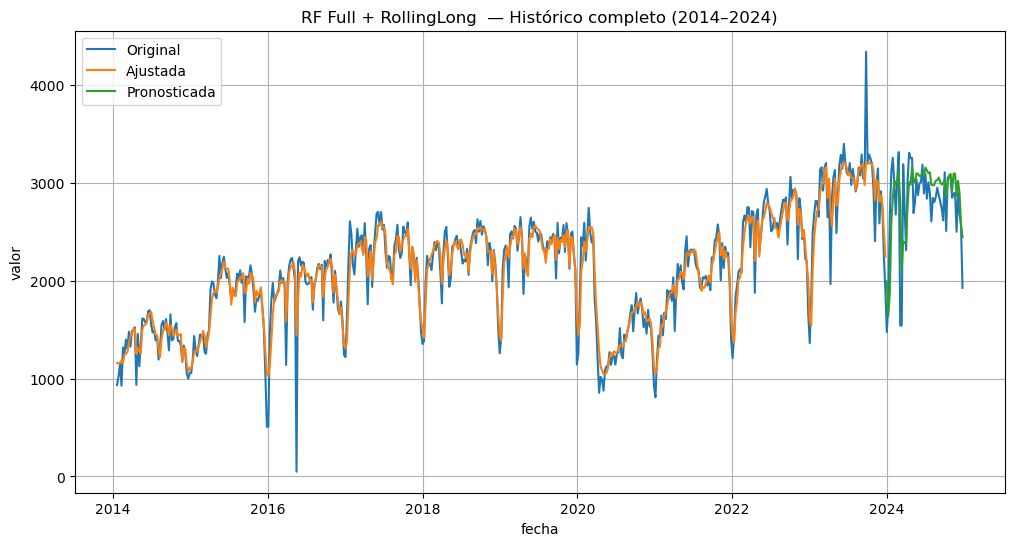

In [ ]:
# Crear dataframes con columnas correctas (cada array/serie como una columna)
df_ajustado = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_train.index].values,
	'valor': y_pred_train
}, index=y_real_train.index)

df_pronostico = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_test.index].values,
	'valor': y_pred_test
}, index=y_real_test.index)

df_pronostico_c = pd.concat([df_ajustado, df_pronostico])

title = "RF Full + RollingLong  — Histórico completo (2014–2024)"

# Los datos a graficar
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
    # (df_pronostico_c, 'Pronosticada Completa'),
)

plot_forecast(
    *data_tuples,  # Desempaqueta los datos
    y='valor',
    title=title,
    **common_plot_args  # Desempaqueta los argumentos comunes
)

# Grafica solo de prueba
# Los datos a graficar
# data_tuples = (
#     (df_test, 'Real'),
#     (df_pronostico, 'Pronosticada'),
# )

# plot_forecast(
#     *data_tuples,  # Desempaqueta los datos
#     y='valor',
#     title=title,
#     **common_plot_args  # Desempaqueta los argumentos comunes
# )

Se revela una disparidad significativa en el error absoluto entre los conjuntos, indicativa de un sobreajuste (overfitting). En el conjunto de entrenamiento, el modelo logra una alta precisión con un Error Absoluto Medio (MAE) de 103.09 y una Raíz del Error Cuadrático Medio (RMSE) de 158.03. No obstante, en el conjunto de prueba, el MAE se incrementa a 249.41 y el RMSE a 339.80, lo que implica una pérdida considerable de capacidad predictiva al generalizar a datos no observados. A pesar de este deterioro en la precisión absoluta, el Error Porcentual Absoluto Medio (MAPE) en la prueba es ligeramente inferior (10.33%) al de entrenamiento (11.22%). Este patrón sugiere que, aunque el error de pronóstico en unidades de casos es mayor en datos no vistos, el error es proporcionalmente menor respecto a la magnitud de los valores reales en el periodo de prueba, lo que ofrece una estabilidad porcentual aceptable para el pronóstico de casos semanales de depresión.

In [ ]:
long_roll_metrics = walk_forward_cv(df_rf_long, features_full_long, target, n_splits=4, model_name="Longer Rolling Model")


Longer Rolling Model
Walk-forward (4): MAE medio: 247.15 ± 64.51 |  RMSE medio: 309.03 ± 72.15 |  MAPE medio: 0.19 ± 0.14


### 3.5. Modelo 5: RF + XGBoost

* Se definen los datos y su división de conjuntos de entrenamiento y prueba

In [ ]:
df_xgb = df.dropna(subset=features_full_long + [target]).copy()

train_df, test_df = temporal_split(df_xgb, test_weeks=52)
X_train, y_train = train_df[features_full_long], train_df[target]
X_test,  y_test  = test_df[features_full_long],  test_df[target]

#### 3.5.1. Búsqueda de hiperparámetros y entrenamiento

* Se hace una búsqueda de parámetros para guiar el proceso. Primeramente prepatando el modelo y el espacio de parámetros.

In [ ]:
# Definir el modelo base
# Establecemos los parámetros que no cambiarán en la búsqueda
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    seed=42,
    # El early_stopping_rounds se aplica después del fit() en un flujo normal,
    # pero RandomizedSearchCV lo maneja automáticamente con 'n_estimators'
)

# Definir el espacio de parámetros a explorar
param_dist = {
    'learning_rate': [0.005, 0.01, 0.02],     # Equivalente a 'eta'
    'n_estimators': [1000, 3000, 5000],       # Equivalente a 'num_boost_round'
    'max_depth': [3, 4, 5, 6],                # Profundidad muy limitada
    'min_child_weight': [15, 30, 50],         # Restricción alta para hojas
    'subsample': [0.6, 0.7, 0.8],             # Mayor submuestreo de filas
    'colsample_bytree': [0.6, 0.7, 0.8],      # Mayor submuestreo de columnas
    'reg_lambda': [5, 10, 20],                # Regularización L2 (lambda)
    'reg_alpha': [5, 10, 20],                 # Regularización L1 (alpha)
    'gamma': [0.0, 0.1, 0.5]                  # Mínima reducción de pérdida requerida
}

* Obtenición de los mejores parámetros. Ejecución de la Búsqueda Aleatoria

In [ ]:
# Ejecución de la búsqueda
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=50,                  # Número de combinaciones a probar
    scoring='neg_root_mean_squared_error', # Usamos RMSE negativo
    cv=5,                       # Validación Cruzada de 5 pliegues
    verbose=2,
    random_state=42,
    n_jobs=-1                   
)

print("Iniciando la búsqueda aleatoria con regularización extrema para XGBoost...")

# Asegúrate de usar X_train y y_train como DataFrames/arrays, NO como DMatrix.
random_search_xgb.fit(X_train, y_train) 

Iniciando la búsqueda aleatoria con regularización extrema para XGBoost...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric='rmse',
                                          feature_types=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rat...
                   n_iter=50, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8],
                                        'gamma': [0.0, 0.1, 0.5],
                                        'learning_rate': [0.005, 0.01, 0.02],
                                        'max_depth': [3, 4, 5, 6],
                                        'min_child_weight': [15, 30, 50],
                                        'n_estimators': [1000, 3000, 5000],
                                        'reg_alpha': [5, 10, 20],
                                        'reg_lambda': [5, 10, 20],
                                        'subsample': [0.6, 0.7, 0.8]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=2)

* Obtención de mejores parámetros

In [ ]:
# 4. Obtención de Resultados
best_rmse_cv = -random_search_xgb.best_score_ 

print("Búsqueda finalizada.")
print(f"Mejor RMSE (Validación Cruzada): {best_rmse_cv:.4f}")
print("Mejores Parámetros:")
print(random_search_xgb.best_params_)

Búsqueda finalizada.
Mejor RMSE (Validación Cruzada): 246.2277
Mejores Parámetros:
{'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 20, 'n_estimators': 5000, 'min_child_weight': 15, 'max_depth': 6, 'learning_rate': 0.02, 'gamma': 0.0, 'colsample_bytree': 0.6}


#### 3.5.2. Evaluación del modelo

##### 3.5.2.1. MAE, RMSE y MAPE
* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [ ]:
params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "eta": 0.02,              
    "max_depth": 6,
    "min_child_weight": 15,
    "subsample": 0.8,
    "colsample_bytree": 0.6,
    "lambda": 5,
    "alpha": 20,
    "gamma": 0.0,
    "seed": 42,
}

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test,  label=y_test)

watch = [(dtrain, "train"), (dtest, "valid")]
model_xgb_full = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=5000,
    evals=watch,
    early_stopping_rounds=300,
    verbose_eval=200
)

y_pred_train = model_xgb_full.predict(dtrain)
y_pred_test  = model_xgb_full.predict(dtest)

model_metrics = meval.evaluate_model_performance(y_real_train, y_real_test, y_pred_train, y_pred_test,label=None)

importance = get_xbg_feature_importance(model_xgb_full, show_importances =True)

[0]	train-rmse:557.96848	valid-rmse:806.56971
[200]	train-rmse:123.52517	valid-rmse:314.54589
[400]	train-rmse:93.85836	valid-rmse:312.95152
[438]	train-rmse:90.70107	valid-rmse:312.07315
Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 56.0711    │
├───────────┼────────────┤
│ RMSE      │ 90.6134    │
├───────────┼────────────┤
│ MAPE      │  0.0650039 │
╘═══════════╧════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤═════════════╕
│ Métrica   │       Valor │
╞═══════════╪═════════════╡
│ MAE       │ 233.055     │
├───────────┼─────────────┤
│ RMSE      │ 311.931     │
├───────────┼─────────────┤
│ MAPE      │   0.0950035 │
╘═══════════╧═════════════╛
Importancia de las features (top 10):

            feature         gain
          rolling_4 2.897427e+06
              lag_1 9.881627e+05
          rolling_8 7.391384e+05
semanas_desde_covid 5.050

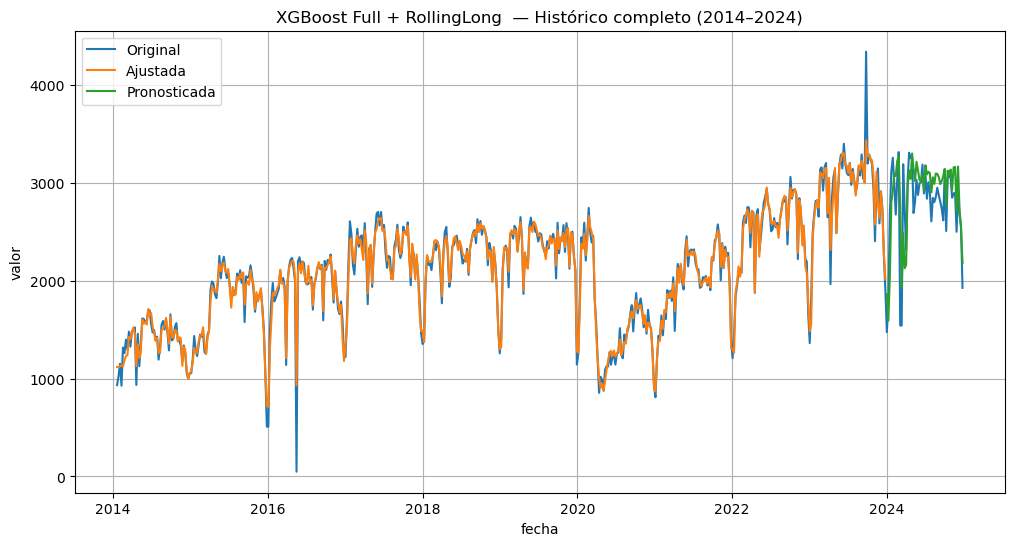

In [ ]:
# Crear dataframes con columnas correctas (cada array/serie como una columna)
df_ajustado = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_train.index].values,
	'valor': y_pred_train
}, index=y_real_train.index)

df_pronostico = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_test.index].values,
	'valor': y_pred_test
}, index=y_real_test.index)

df_pronostico_c = pd.concat([df_ajustado, df_pronostico])

title = "XGBoost Full + RollingLong  — Histórico completo (2014–2024)"

# Los datos a graficar
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
    # (df_pronostico_c, 'Pronosticada Completa'),
)

plot_forecast(
    *data_tuples,  # Desempaqueta los datos
    y='valor',
    title=title,
    **common_plot_args  # Desempaqueta los argumentos comunes
)

# Grafica solo de prueba
# Los datos a graficar
# data_tuples = (
#     (df_test, 'Real'),
#     (df_pronostico, 'Pronosticada'),
# )

# plot_forecast(
#     *data_tuples,  # Desempaqueta los datos
#     y='valor',
#     title=title,
#     **common_plot_args  # Desempaqueta los argumentos comunes
# )

In [ ]:
xgb_rolling_metrics = walk_forward_cv(df_xgb, features_full_long, target, n_splits=4, model_name="XGB + Rolling Model")


XGB + Rolling Model
Walk-forward (4): MAE medio: 247.15 ± 64.51 |  RMSE medio: 309.03 ± 72.15 |  MAPE medio: 0.19 ± 0.14


La gráfica de muestra un desempeño de predicción que, aunque generalmente sigue la **tendencia y estacionalidad** de la **Serie Real** (línea azul), exhibe una **alta volatilidad en los errores puntuales** y una **degradación de la precisión** en los extremos del periodo. Específicamente, en la primera mitad del año 2024, la **Serie Predicha** (línea naranja discontinua) **falla notablemente en capturar los picos y valles abruptos**, presentando una gran discrepancia en las caídas observadas en marzo y los máximos de mayo. Si bien el modelo parece **alinearse mejor** con las fluctuaciones de menor amplitud en la segunda mitad del año, la **incapacidad para replicar los *shocks* y la alta volatilidad** de la serie en el primer trimestre, a pesar de la inclusión de la ventana deslizante (*rolling*), indica que el $\text{XGBoost}$ **no ha capturado completamente la dinámica de cambio rápido** de la serie, lo que afecta negativamente la robustez de las predicciones puntuales. 